<a href="https://colab.research.google.com/github/Chathuranga630/sionna/blob/main/Spoofed_Traffic_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install sionna

In [4]:
pip show sionna


Name: sionna
Version: 2.0.1
Summary: Sionna - A hardware-accelerated differentiable open-source library for research on communication systems
Home-page: 
Author: 
Author-email: The Sionna contributors <sionna@nvidia.com>
License: Apache-2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: h5py, importlib-resources, matplotlib, numpy, scipy, sionna-rt, torch
Required-by: 


In [5]:
import tensorflow as tf
import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

TensorFlow: 2.20.0
Sionna: 2.0.1


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation area (meters)
AREA_X = 1000
AREA_Y = 1000

print("Simulation Area:", AREA_X, "x", AREA_Y, "meters")

Simulation Area: 1000 x 1000 meters


In [7]:
bs_positions = np.array([
    [250,250],
    [750,250],
    [500,750]
])

print(bs_positions)

[[250 250]
 [750 250]
 [500 750]]


In [8]:
num_users = 30

user_positions = np.random.rand(num_users,2)

user_positions[:,0] *= AREA_X
user_positions[:,1] *= AREA_Y

print(user_positions)

[[406.54969434 550.95465849]
 [922.69322786 179.59361131]
 [223.95966836 882.41242951]
 [525.28251521  17.86001061]
 [201.94519635 299.97223904]
 [ 38.00832042 248.16102135]
 [ 28.47528476 808.67836604]
 [269.68002528 632.00728741]
 [ 51.48834147 750.69963044]
 [992.78987455 457.18921294]
 [219.57072635 369.19550211]
 [757.10066086 848.08063297]
 [744.6993036   87.39651474]
 [ 12.4645264  462.55167196]
 [871.21605427 493.30081237]
 [445.46112599 552.13747634]
 [352.3304518  763.93291859]
 [998.72161079  60.41299225]
 [956.39781508 875.28355306]
 [477.51061281  31.81597671]
 [787.33141473 987.25964603]
 [374.45595935 365.38752984]
 [437.55900521 448.20836747]
 [631.77593363 403.95824634]
 [857.67510955 413.20885922]
 [224.86922941 927.29367285]
 [ 80.21246654 893.83726725]
 [664.16529702  92.80523036]
 [ 22.6468067  254.55448089]
 [234.6427128  954.30429488]]


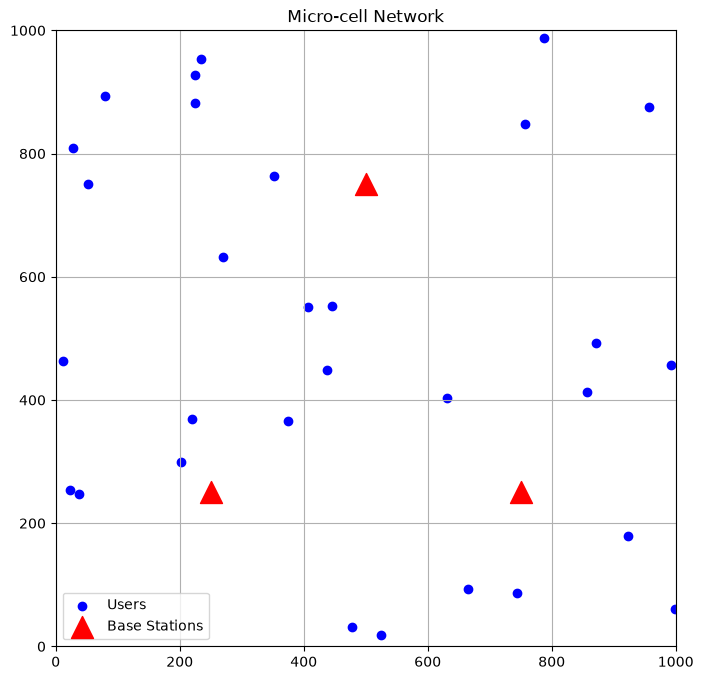

In [9]:
plt.figure(figsize=(8,8))

# Users
plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c='blue',
    label='Users'
)

# Base Stations
plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    c='red',
    s=250,
    marker='^',
    label='Base Stations'
)

plt.xlim(0,AREA_X)
plt.ylim(0,AREA_Y)

plt.grid(True)
plt.legend()

plt.title("Micro-cell Network")

plt.savefig("figures_network_layout_1.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
import tensorflow as tf
import sionna
import numpy as np
import matplotlib.pyplot as plt


# Distance matrix
distance_matrix = np.zeros((len(user_positions), len(bs_positions)))

for i, user in enumerate(user_positions):

    for j, bs in enumerate(bs_positions):

        distance = np.linalg.norm(user-bs)

        distance_matrix[i,j] = distance

print(distance_matrix)

[[339.23666262 456.65284289 219.89089933]
 [676.36767987 186.49399593 709.95282458]
 [632.94832323 822.59583728 306.15570578]
 [360.09642855 323.08965109 732.57639167]
 [ 69.32884557 550.3283497  539.77926194]
 [211.99965579 711.9940545  682.11338683]
 [600.99477215 912.53461929 475.16177006]
 [382.51388345 613.70745942 258.78479666]
 [538.61581716 859.42926238 448.51220421]
 [771.14471255 319.17752607 573.21899609]
 [123.01832553 543.65686059 472.91927761]
 [784.12468637 598.12278247 275.17369129]
 [520.73726044 162.68986079 706.34349142]
 [318.74961094 767.55246601 565.96588176]
 [667.16165311 271.82460726 451.32674625]
 [359.85011655 428.98832198 205.24148472]
 [524.02153217 649.82160196 148.32539123]
 [772.3517877  312.73898571 851.03083747]
 [943.38613244 658.46759966 473.28103097]
 [315.22269423 349.07697454 718.53605605]
 [912.29207763 738.20418597 372.62780562]
 [169.71613907 392.87098201 404.5838088 ]
 [272.88264396 370.00801634 308.18349614]
 [411.65034327 194.11355307 370.28

In [11]:
assignments = np.argmin(distance_matrix, axis=1)

print(assignments)

[2 1 2 1 0 0 2 2 2 1 0 2 1 0 1 2 2 1 2 0 2 0 0 1 1 2 2 1 0 2]


In [12]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments==bs)

    print(f"BS {bs+1} has {count} users")

BS 1 has 8 users
BS 2 has 9 users
BS 3 has 13 users


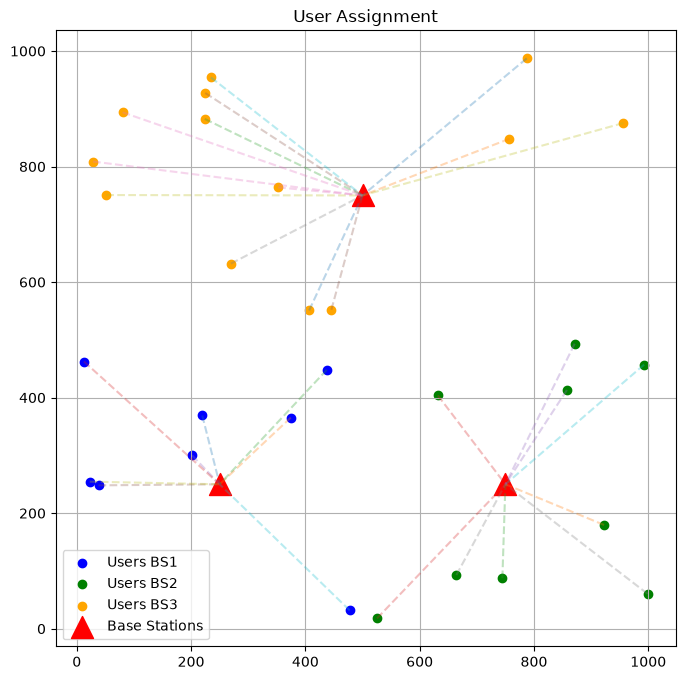

In [13]:
plt.figure(figsize=(8,8))

colors=['blue','green','orange']

# Draw users

for bs in range(3):

    idx = assignments==bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users BS{bs+1}'
    )

# Draw Base Stations

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=250,
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs=assignments[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3
    )

plt.grid()

plt.legend()

plt.title("User Assignment")

plt.savefig("figures_network_layout_2.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
import pandas as pd

results = pd.DataFrame({
    "User": range(1, len(assignments)+1),
    "Assigned_BS": assignments
})

results.to_csv("user_assignment.csv", index=False)

In [15]:
# -------------------------------
# Network Parameters
# -------------------------------

frequency = 3500      # MHz (5G frequency)
tx_power = 30         # dBm (micro-cell transmit power)

print("Frequency:", frequency, "MHz")
print("Transmit Power:", tx_power, "dBm")

Frequency: 3500 MHz
Transmit Power: 30 dBm


In [16]:
distance_matrix
print(distance_matrix)

[[339.23666262 456.65284289 219.89089933]
 [676.36767987 186.49399593 709.95282458]
 [632.94832323 822.59583728 306.15570578]
 [360.09642855 323.08965109 732.57639167]
 [ 69.32884557 550.3283497  539.77926194]
 [211.99965579 711.9940545  682.11338683]
 [600.99477215 912.53461929 475.16177006]
 [382.51388345 613.70745942 258.78479666]
 [538.61581716 859.42926238 448.51220421]
 [771.14471255 319.17752607 573.21899609]
 [123.01832553 543.65686059 472.91927761]
 [784.12468637 598.12278247 275.17369129]
 [520.73726044 162.68986079 706.34349142]
 [318.74961094 767.55246601 565.96588176]
 [667.16165311 271.82460726 451.32674625]
 [359.85011655 428.98832198 205.24148472]
 [524.02153217 649.82160196 148.32539123]
 [772.3517877  312.73898571 851.03083747]
 [943.38613244 658.46759966 473.28103097]
 [315.22269423 349.07697454 718.53605605]
 [912.29207763 738.20418597 372.62780562]
 [169.71613907 392.87098201 404.5838088 ]
 [272.88264396 370.00801634 308.18349614]
 [411.65034327 194.11355307 370.28

In [17]:
distance_km = distance_matrix / 1000

# Avoid log10(0)
distance_km[distance_km < 0.001] = 0.001

import numpy as np

path_loss = 32.44 \
            + 20*np.log10(frequency) \
            + 20*np.log10(distance_km)

print(path_loss)

[[ 93.93141653  96.5130842   90.165506  ]
 [ 99.92501782  88.73465798 100.34595071]
 [ 99.34872596 101.62509104  93.04020804]
 [ 94.44973717  93.50782183 100.61841926]
 [ 80.13964026  98.1337986   97.96568479]
 [ 89.848064   100.37088823  99.99849234]
 [ 98.89877477 102.52634788  96.85819072]
 [ 94.97430494  99.08058893  91.58013605]
 [ 97.94694294 102.00556362  96.35684618]
 [101.06407859  93.40200697  98.48777237]
 [ 85.12075711  98.02785835  96.81710124]
 [101.20906342  98.85716779  92.11349908]
 [ 97.65373397  87.54857064 100.30167984]
 [ 93.39035415 101.02352231  98.37716591]
 [ 99.80598241  92.00713627  96.41118231]
 [ 94.44379384  95.97027028  89.56666384]
 [ 97.70834354  99.57724378  86.74567094]
 [101.07766401  93.22500135 101.92026683]
 [102.81515065  99.69204909  96.82374285]
 [ 93.29371042  94.17978495 100.4503322 ]
 [102.52403896 100.68489096  94.74686607]
 [ 87.91582375  95.20635994  95.46153086]
 [ 92.04087917  94.68558355  93.09754844]
 [ 95.61193053  89.08247807  94.69

In [18]:
received_power = tx_power - path_loss

print(received_power)

[[-63.93141653 -66.5130842  -60.165506  ]
 [-69.92501782 -58.73465798 -70.34595071]
 [-69.34872596 -71.62509104 -63.04020804]
 [-64.44973717 -63.50782183 -70.61841926]
 [-50.13964026 -68.1337986  -67.96568479]
 [-59.848064   -70.37088823 -69.99849234]
 [-68.89877477 -72.52634788 -66.85819072]
 [-64.97430494 -69.08058893 -61.58013605]
 [-67.94694294 -72.00556362 -66.35684618]
 [-71.06407859 -63.40200697 -68.48777237]
 [-55.12075711 -68.02785835 -66.81710124]
 [-71.20906342 -68.85716779 -62.11349908]
 [-67.65373397 -57.54857064 -70.30167984]
 [-63.39035415 -71.02352231 -68.37716591]
 [-69.80598241 -62.00713627 -66.41118231]
 [-64.44379384 -65.97027028 -59.56666384]
 [-67.70834354 -69.57724378 -56.74567094]
 [-71.07766401 -63.22500135 -71.92026683]
 [-72.81515065 -69.69204909 -66.82374285]
 [-63.29371042 -64.17978495 -70.4503322 ]
 [-72.52403896 -70.68489096 -64.74686607]
 [-57.91582375 -65.20635994 -65.46153086]
 [-62.04087917 -64.68558355 -63.09754844]
 [-65.61193053 -59.08247807 -64.69

In [19]:
assignments_signal = np.argmax(received_power, axis=1)

print(assignments_signal)


[2 1 2 1 0 0 2 2 2 1 0 2 1 0 1 2 2 1 2 0 2 0 0 1 1 2 2 1 0 2]


In [20]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments_signal == bs)

    print(f"BS {bs+1}: {count} users")

BS 1: 8 users
BS 2: 9 users
BS 3: 13 users


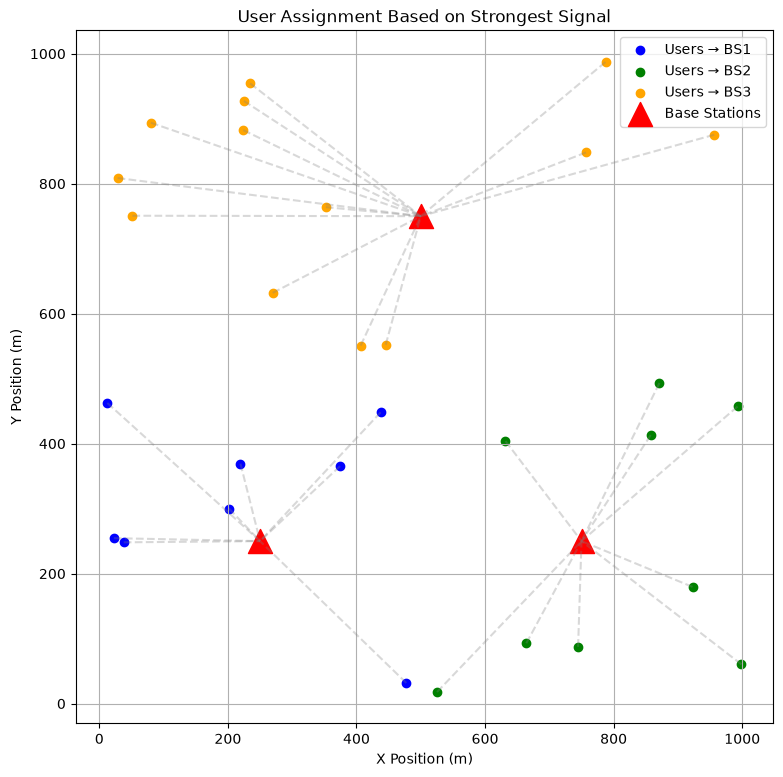

In [21]:
plt.figure(figsize=(9,9))

colors = ['blue','green','orange']

for bs in range(3):

    idx = assignments_signal == bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users → BS{bs+1}'
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    s=300,
    color='red',
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs = assignments_signal[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3,
        color='gray'
    )

plt.title("User Assignment Based on Strongest Signal")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step4_user_assignment_signal.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [22]:
import pandas as pd

results = pd.DataFrame({
    "User": np.arange(1, len(user_positions)+1),
    "Assigned_BS": assignments_signal + 1,
    "Best_RSRP_dBm": np.max(received_power, axis=1)
})

print(results.head())

results.to_csv("step4_user_assignment.csv", index=False)

   User  Assigned_BS  Best_RSRP_dBm
0     1            3     -60.165506
1     2            2     -58.734658
2     3            3     -63.040208
3     4            2     -63.507822
4     5            1     -50.139640


In [23]:
#STEP 5 - SINR Calculation
# Convert dBm to mW

received_power_mW = 10 ** (received_power / 10)

print(received_power_mW)

[[4.04443954e-07 2.23198658e-07 9.62607853e-07]
 [1.01741519e-07 1.33824060e-06 9.23432018e-08]
 [1.16178938e-07 6.87845494e-08 4.96568534e-07]
 [3.58943657e-07 4.45879820e-07 8.67277488e-08]
 [9.68358065e-06 1.53680987e-07 1.59746562e-07]
 [1.03560372e-06 9.18144796e-08 1.00034721e-07]
 [1.28861304e-07 5.58940028e-08 2.06148856e-07]
 [3.18104275e-07 1.23577984e-07 6.95002544e-07]
 [1.60437433e-07 6.30149561e-08 2.31374440e-07]
 [7.82694246e-08 4.56877008e-07 1.41652017e-07]
 [3.07556060e-06 1.57475924e-07 2.08108527e-07]
 [7.56996127e-08 1.30101775e-07 6.14681429e-07]
 [1.71643200e-07 1.75850228e-06 9.32893390e-08]
 [4.58104528e-07 7.90037614e-08 1.45305954e-07]
 [1.04568712e-07 6.29921415e-07 2.28497666e-07]
 [3.59435208e-07 2.52914059e-07 1.10492708e-06]
 [1.69498417e-07 1.10223862e-07 2.11559682e-06]
 [7.80249680e-08 4.75882643e-07 6.42648232e-08]
 [5.22979825e-08 1.07348280e-07 2.07790513e-07]
 [4.68413020e-07 3.81963184e-07 9.01502177e-08]
 [5.59237267e-08 8.54104292e-08 3.352072

In [24]:
# Thermal Noise (Assume a simple fixed thermal noise power)
noise_dBm = -100

noise_mW = 10 ** (noise_dBm / 10)

print("Noise Power (mW):", noise_mW)

Noise Power (mW): 1e-10


In [25]:
# Calculate SINR
sinr = []

for i in range(len(user_positions)):

    serving_bs = assignments_signal[i]

    signal = received_power_mW[i, serving_bs]

    interference = np.sum(received_power_mW[i]) - signal

    sinr_linear = signal / (interference + noise_mW)

    sinr.append(sinr_linear)

sinr = np.array(sinr)

# Convert SINR to dB
sinr_dB = 10 * np.log10(sinr)

print(sinr_dB)

[ 1.85667790e+00  8.38319147e+00  4.28658453e+00  1.05609574e-03
  1.48976027e+01  7.32007292e+00  4.73490049e-01  1.96778122e+00
  1.49360654e-01  3.17334297e+00  9.24817794e+00  4.74990819e+00
  8.21843739e+00  3.09922931e+00  2.76625205e+00  2.56263497e+00
  8.78550618e+00  5.24021012e+00  1.14195008e+00 -3.50935032e-02
  3.74759091e+00  4.40520670e+00 -1.23232036e+00  3.03419307e+00
  5.93380191e+00  4.21013405e+00  1.72182302e+00  6.31830863e+00
  6.83825274e+00  4.27725277e+00]


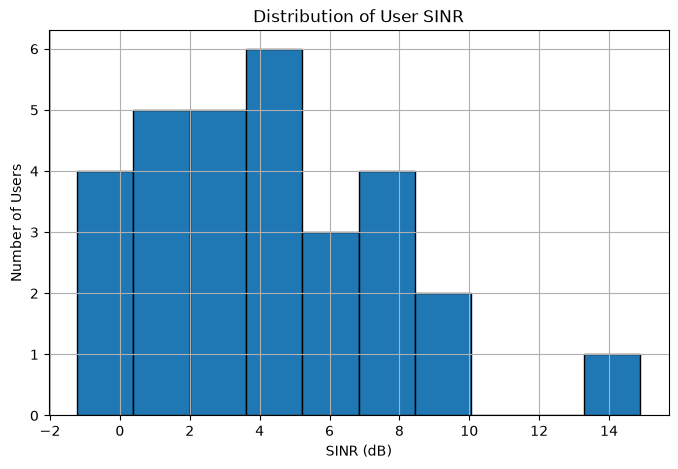

In [26]:
# Plot SINR Distribution
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=10,
         edgecolor='black')

plt.xlabel("SINR (dB)")
plt.ylabel("Number of Users")
plt.title("Distribution of User SINR")

plt.grid(True)

plt.savefig("figures_step5_sinr_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

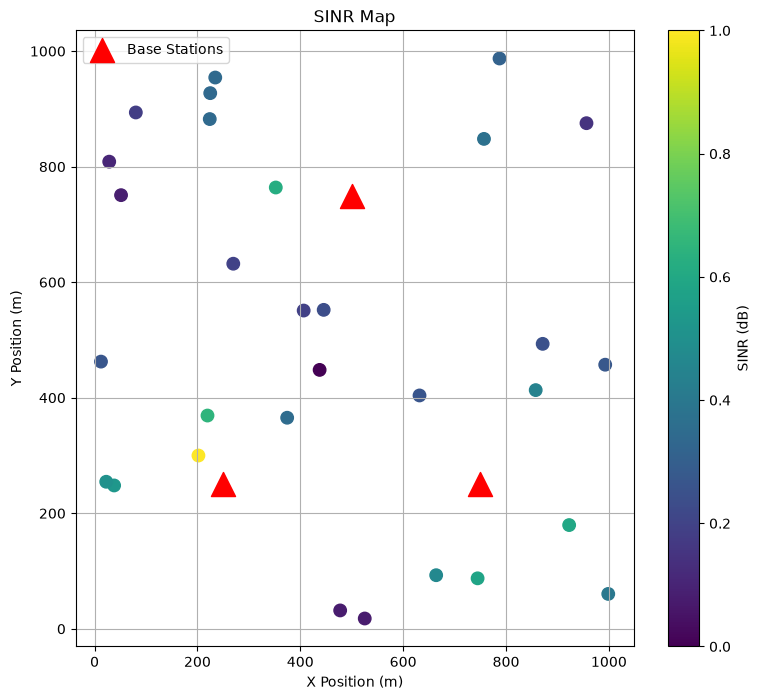

In [27]:
# Network Visualization
plt.figure(figsize=(9,8))

plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c=sinr_dB,
    cmap='viridis',
    s=80
)

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=300,
    label='Base Stations'
)

plt.colorbar(label="SINR (dB)")

plt.title("SINR Map")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step5_sinr_map.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [28]:
# Statistics
print("Average SINR :", np.mean(sinr_dB))

print("Maximum SINR :", np.max(sinr_dB))

print("Minimum SINR :", np.min(sinr_dB))

Average SINR : 4.2513538870019385
Maximum SINR : 14.89760266878603
Minimum SINR : -1.2323203595882035


In [29]:
# Save Results
results["SINR_dB"] = sinr_dB

results.to_csv(
    "results_step5_sinr_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm    SINR_dB
0     1            3     -60.165506   1.856678
1     2            2     -58.734658   8.383191
2     3            3     -63.040208   4.286585
3     4            2     -63.507822   0.001056
4     5            1     -50.139640  14.897603


In [30]:
#====================================================
# STEP 6 - QoS Analysis
#====================================================

# Spectral Efficiency (bits/s/Hz)

spectral_efficiency = np.log2(1 + sinr)

print(spectral_efficiency)


[1.34109968 2.98031518 1.88097283 1.00017542 4.99484672 2.67698876
 1.0807875  1.36355178 1.02502156 1.62129529 3.23425944 1.99469539
 2.93263627 1.60472402 1.5314245  1.48754398 3.09769536 2.11839697
 1.20210643 0.99418287 1.75277369 1.90978566 0.80978745 1.59025876
 2.29890744 1.86251597 1.31415096 2.40158037 2.54316053 1.87871518]


In [31]:
# Bandwidth per user

bandwidth = 20e6      # 20 MHz

throughput = bandwidth * spectral_efficiency

throughput_Mbps = throughput / 1e6

print(throughput_Mbps)

[26.82199354 59.60630355 37.61945651 20.00350849 99.89693433 53.53977516
 21.61575008 27.27103566 20.50043112 32.42590575 64.68518878 39.89390781
 58.65272547 32.09448041 30.62848998 29.75087953 61.95390714 42.36793939
 24.04212865 19.88365741 35.05547386 38.19571311 16.19574905 31.80517526
 45.97814885 37.25031934 26.28301926 48.03160748 50.86321054 37.57430354]


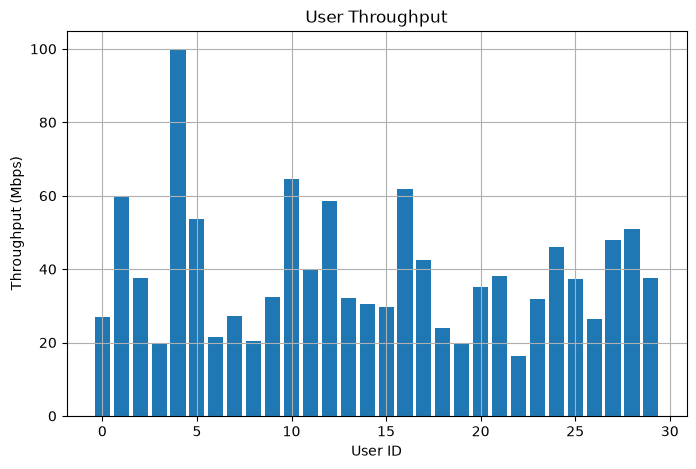

In [32]:
# Plot Throughput

plt.figure(figsize=(8,5))

plt.bar(range(len(throughput_Mbps)),
        throughput_Mbps)

plt.xlabel("User ID")
plt.ylabel("Throughput (Mbps)")
plt.title("User Throughput")

plt.grid(True)

plt.savefig(
    "figures_step6_throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# Average Throughput
print("Average Throughput:")

print(np.mean(throughput_Mbps),"Mbps")

Average Throughput:
39.01623730072562 Mbps


In [34]:
# Packet Error Rate (PER)
packet_error_rate = np.exp(-sinr)

print(packet_error_rate)

[2.15791301e-01 1.01630124e-03 6.83418194e-02 3.67789982e-01
 3.85854775e-14 4.53832713e-03 3.27852864e-01 2.07384871e-01
 3.55230008e-01 1.25366818e-01 2.22535900e-04 5.05233585e-02
 1.31352232e-03 1.29849960e-01 1.50964399e-01 1.64620574e-01
 5.20613966e-04 3.53621906e-02 2.72326514e-01 3.70852087e-01
 9.34752452e-02 6.34481216e-02 4.70973633e-01 1.33850268e-01
 1.98242436e-02 7.16177190e-02 2.26149382e-01 1.37899318e-02
 7.99735061e-03 6.87365574e-02]


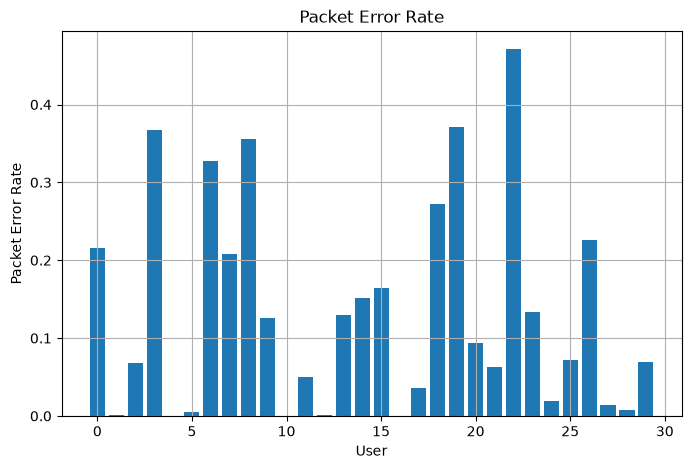

In [35]:
# Plot PER
plt.figure(figsize=(8,5))

plt.bar(range(len(packet_error_rate)),
        packet_error_rate)

plt.xlabel("User")

plt.ylabel("Packet Error Rate")

plt.title("Packet Error Rate")

plt.grid(True)

plt.savefig(
    "figures_step6_packet_error_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# Latency Model
latency = 100/(sinr+1)

print(latency)

[39.47196709 12.67172487 27.1500578  49.99392062  3.13618241 15.63673535
 47.27706882 38.86243536 49.14029569 32.50435007 10.62651587 25.09209108
 13.09750326 32.87985814 34.59356258 35.66191358 11.68155828 23.03026681
 43.4640214  50.20201334 29.67307422 26.61320825 57.04658967 33.21118804
 20.32169377 27.49962848 40.21621012 18.92571389 17.15664628 27.19257772]


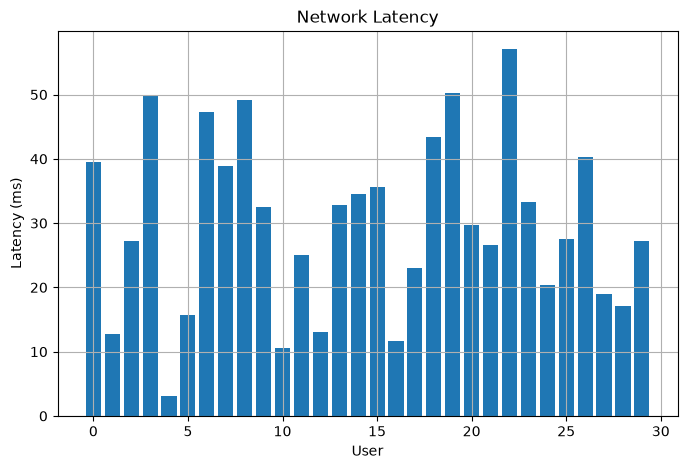

In [37]:
# Plot Latency
plt.figure(figsize=(8,5))

plt.bar(range(len(latency)),
        latency)

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Network Latency")

plt.grid(True)

plt.savefig(
    "figures_step6_latency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# QoS Summary
print("========== QoS SUMMARY ==========")

print("Average SINR:",
      np.mean(sinr_dB),
      "dB")

print("Average Throughput:",
      np.mean(throughput_Mbps),
      "Mbps")

print("Average Latency:",
      np.mean(latency),
      "ms")

print("Average PER:",
      np.mean(packet_error_rate))

========== QoS SUMMARY ==========
Average SINR: 4.2513538870019385 dB
Average Throughput: 39.01623730072562 Mbps
Average Latency: 29.801019095615892 ms
Average PER: 0.13399101663459806


In [39]:
# Save Results
results["SINR_dB"] = sinr_dB
results["Spectral_Efficiency"] = spectral_efficiency
results["Throughput_Mbps"] = throughput_Mbps
results["Latency_ms"] = latency
results["PER"] = packet_error_rate

results.to_csv(
    "results_step6_qos_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm    SINR_dB  Spectral_Efficiency  \
0     1            3     -60.165506   1.856678             1.341100   
1     2            2     -58.734658   8.383191             2.980315   
2     3            3     -63.040208   4.286585             1.880973   
3     4            2     -63.507822   0.001056             1.000175   
4     5            1     -50.139640  14.897603             4.994847   

   Throughput_Mbps  Latency_ms           PER  
0        26.821994   39.471967  2.157913e-01  
1        59.606304   12.671725  1.016301e-03  
2        37.619457   27.150058  6.834182e-02  
3        20.003508   49.993921  3.677900e-01  
4        99.896934    3.136182  3.858548e-14  


In [40]:
# Step 7
# Save normal network results

normal_throughput = throughput_Mbps.copy()
normal_latency = latency.copy()
normal_per = packet_error_rate.copy()
normal_assignments = assignments_signal.copy()

In [41]:
# Number of users connected to each BS

cell_load = np.zeros(len(bs_positions), dtype=int)

for bs in assignments_signal:
    cell_load[bs] += 1

print("Current Cell Load")

for i, load in enumerate(cell_load):
    print(f"BS{i+1}: {load} users")

Current Cell Load
BS1: 8 users
BS2: 9 users
BS3: 13 users


In [42]:
#----------------------------------------
# Spoofed Traffic Attack
#----------------------------------------

target_bs = 1      # BS2 (index starts from 0)

spoofed_users = 20

print("Attack Target : BS", target_bs+1)
print("Fake Users :", spoofed_users)

Attack Target : BS 2
Fake Users : 20


In [43]:
# Increase Cell Load
attack_cell_load = cell_load.copy()

attack_cell_load[target_bs] += spoofed_users

print("Cell Load After Attack")

for i, load in enumerate(attack_cell_load):
    print(f"BS{i+1}: {load} users")

Cell Load After Attack
BS1: 8 users
BS2: 29 users
BS3: 13 users


In [44]:
# Available Bandwidth Per Cell
total_bandwidth = 20e6      #20 MHz

bandwidth_per_bs = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):
    bandwidth_per_bs[i] = total_bandwidth / attack_cell_load[i]

print(bandwidth_per_bs)

[2500000.          689655.17241379 1538461.53846154]


In [45]:
# Calculate New Throughput
attack_throughput = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    attack_bandwidth = bandwidth_per_bs[bs]

    attack_throughput[i] = (
        attack_bandwidth
        * spectral_efficiency[i]
        / 1e6
    )

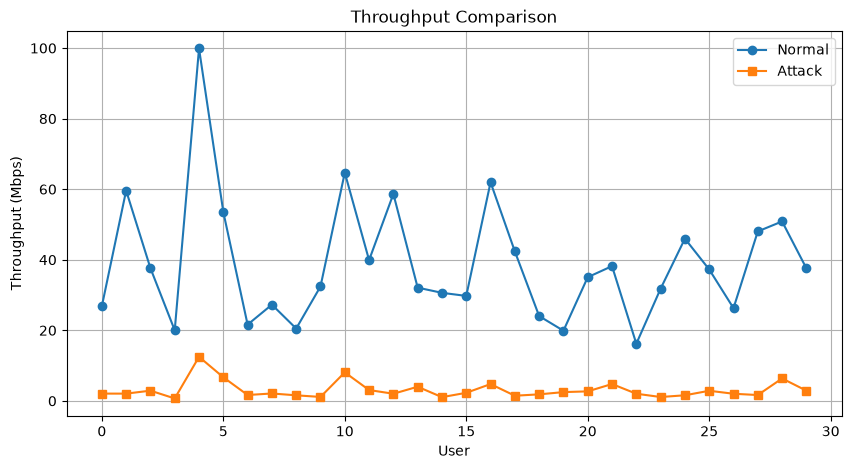

In [46]:
# Plot Throughput Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_throughput,
         marker='o',
         label="Normal")

plt.plot(attack_throughput,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Throughput (Mbps)")

plt.title("Throughput Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_throughput_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# New Latency
attack_latency = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    load_factor = attack_cell_load[bs] / cell_load[bs]

    attack_latency[i] = latency[i] * load_factor

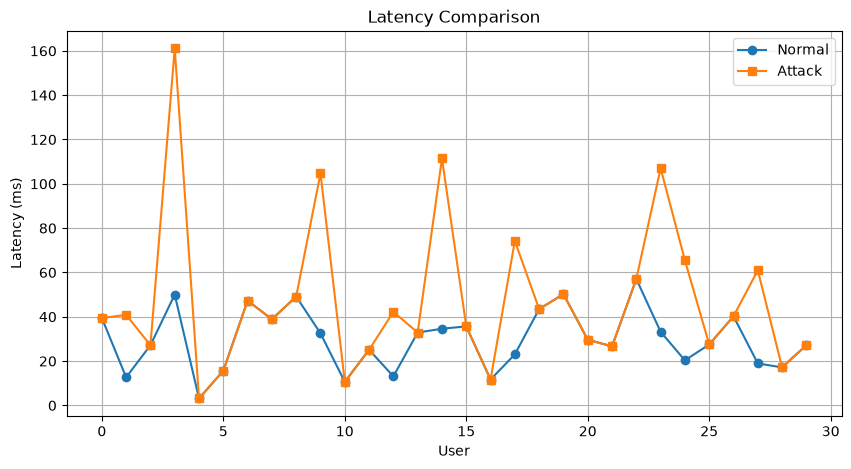

In [48]:
# Plot Latency Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_latency,
         marker='o',
         label="Normal")

plt.plot(attack_latency,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Latency Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_latency_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# QoS Comparison
print("========== NORMAL ==========")

print("Average Throughput:",
      np.mean(normal_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(normal_latency),
      "ms")

print("\n========== ATTACK ==========")

print("Average Throughput:",
      np.mean(attack_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(attack_latency),
      "ms")

========== NORMAL ==========
Average Throughput: 39.01623730072562 Mbps
Average Latency: 29.801019095615892 ms

========== ATTACK ==========
Average Throughput: 3.080056028358484 Mbps
Average Latency: 47.45656901528301 ms


In [50]:
# Save Results
attack_results = results.copy()

attack_results["Attack_Throughput_Mbps"] = attack_throughput
attack_results["Attack_Latency_ms"] = attack_latency

attack_results.to_csv(
    "results_step7_attack_results.csv",
    index=False
)

In [51]:
# ====================================================
# STEP 7A - Legitimate Traffic Generation
# ====================================================

# Simulation Parameters
import numpy as np

simulation_time = 10          # seconds

packet_size = 1500            # Bytes

time_step = 1                 # second

# Legitimate Traffic
np.random.seed(42)

traffic_rate = np.random.randint(5,16,size=len(user_positions))

print(traffic_rate)

# Total Legitimate Packets
legitimate_packets = traffic_rate * simulation_time

print(legitimate_packets)

[11  8 15 12  9 11 14  7 11 15 15 12  9  8 12 12  7 10  9  6 12 10  6  9
  5 14 10 13  5 15]
[110  80 150 120  90 110 140  70 110 150 150 120  90  80 120 120  70 100
  90  60 120 100  60  90  50 140 100 130  50 150]


In [52]:
# Spoofed Traffic
attack_levels = {
    "Normal":0,
    "Low":50,
    "Medium":200,
    "High":500
}

target_bs = 1 # Suppose the attacker targets BS2

spoofed_packets = attack_levels["Medium"] * simulation_time

print(spoofed_packets)

2000


In [53]:
# Base Station Load
bs_packets = np.zeros(len(bs_positions))

for i,bs in enumerate(assignments_signal):

    bs_packets[bs] += legitimate_packets[i]

print(bs_packets)

# Inject Attack
attack_packets = bs_packets.copy()

attack_packets[target_bs] += spoofed_packets

print(attack_packets)

[ 700.  930. 1490.]
[ 700. 2930. 1490.]


In [54]:
# Queue Model
bs_capacity = 2000      # packets

queue = np.maximum(
    attack_packets-bs_capacity,
    0
)

print(queue)

[  0. 930.   0.]


In [55]:
# Queue Delay
queue_delay = queue / bs_capacity

print(queue_delay)

[0.    0.465 0.   ]


In [56]:
# User Latency
attack_latency = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    attack_latency[i] = latency[i] + queue_delay[bs]*1000

In [57]:
# Throughput Reduction
bs_capacity_Mbps = 1000

attack_throughput = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    load = attack_packets[bs]

    attack_throughput[i] = (
        throughput_Mbps[i]
        *
        bs_capacity
        /
        load
    )

In [58]:
# Packet Loss
packet_loss = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):

    if attack_packets[i] > bs_capacity:

        packet_loss[i] = (
            attack_packets[i]-bs_capacity
        ) / attack_packets[i]
packet_loss1 = packet_loss*100
print(packet_loss1, "%")

[ 0.         31.74061433  0.        ] %


In [59]:
# Visulaization --- do later Base Station Queue Length vs Attack Level
# Throughput vs Attack Level
# Latency vs Attack Level
# Packet Loss vs Attack Level
# Cell Load vs Attack Level
# User Assignment Map
# QoS Heat Map

In [60]:
# ====================================================
# STEP 8 - Impact Assessment
# ====================================================

attack_levels = {
    "Normal": 0,
    "Low": 50,
    "Medium": 200,
    "High": 500
}

bs_capacity = 2000          # packets
simulation_time = 10        # seconds
target_bs = 1               # BS2

# Create Lists to Store Results
average_throughput = []
average_latency = []
average_packet_loss = []
average_queue = []

# Run All Attack Scenarios
for attack_name, attack_rate in attack_levels.items():

    spoofed_packets = attack_rate * simulation_time

    attack_packets = bs_packets.copy()

    attack_packets[target_bs] += spoofed_packets

    queue = np.maximum(attack_packets-bs_capacity,0)

    queue_delay = queue/bs_capacity

    attack_latency = np.zeros(len(user_positions))

    attack_throughput = np.zeros(len(user_positions))

    for i,bs in enumerate(assignments_signal):

        attack_latency[i] = latency[i] + queue_delay[bs]*1000

        attack_throughput[i] = (
            throughput_Mbps[i]
            *
            bs_capacity
            /
            attack_packets[bs]
        )

    packet_loss = np.zeros(len(bs_positions))

    for bs in range(len(bs_positions)):

        if attack_packets[bs] > bs_capacity:

            packet_loss[bs] = (
                attack_packets[bs]-bs_capacity
            )/attack_packets[bs]

    average_throughput.append(np.mean(attack_throughput))

    average_latency.append(np.mean(attack_latency))

    average_packet_loss.append(np.mean(packet_loss))

    average_queue.append(np.mean(queue))

# Display Results
import pandas as pd

impact_results = pd.DataFrame({

    "Attack_Level": attack_levels.keys(),

    "Avg_Throughput_Mbps": average_throughput,

    "Avg_Latency_ms": average_latency,

    "Avg_Queue_Packets": average_queue,

    "Avg_Packet_Loss": average_packet_loss

})

print(impact_results)


  Attack_Level  Avg_Throughput_Mbps  Avg_Latency_ms  Avg_Queue_Packets  \
0       Normal            81.279473       29.801019                0.0   
1          Low            72.018130       29.801019                0.0   
2       Medium            63.199309      169.301019              310.0   
3         High            58.946049      619.301019             1310.0   

   Avg_Packet_Loss  
0         0.000000  
1         0.000000  
2         0.105802  
3         0.220911  


In [61]:
# Save Results
impact_results.to_csv(
    "results_step8_impact_assessment.csv",
    index=False
)

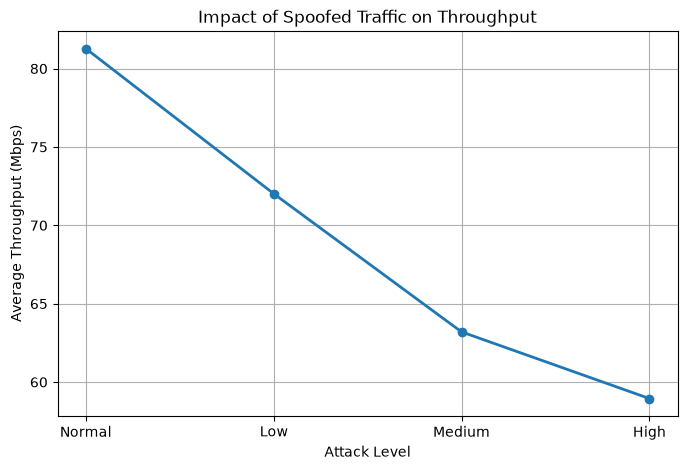

In [62]:
# Throughput vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Throughput_Mbps"],
    marker='o',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Throughput (Mbps)")

plt.title("Impact of Spoofed Traffic on Throughput")

plt.grid(True)

plt.savefig(
    "figures_step8_throughput_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

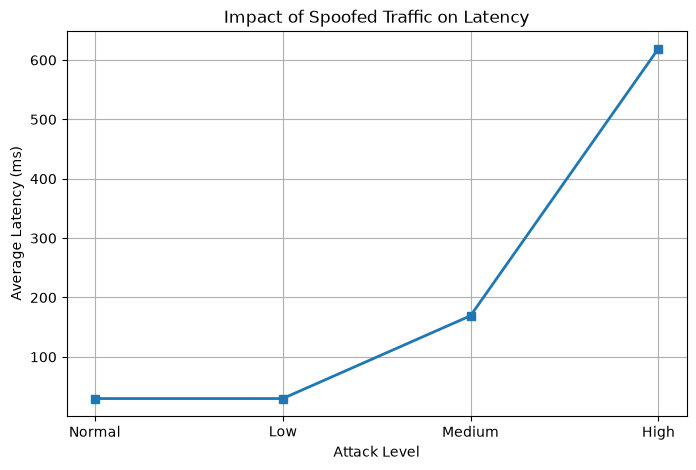

In [63]:
#Latency vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Latency_ms"],
    marker='s',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Latency (ms)")

plt.title("Impact of Spoofed Traffic on Latency")

plt.grid(True)

plt.savefig(
    "figures_step8_latency_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

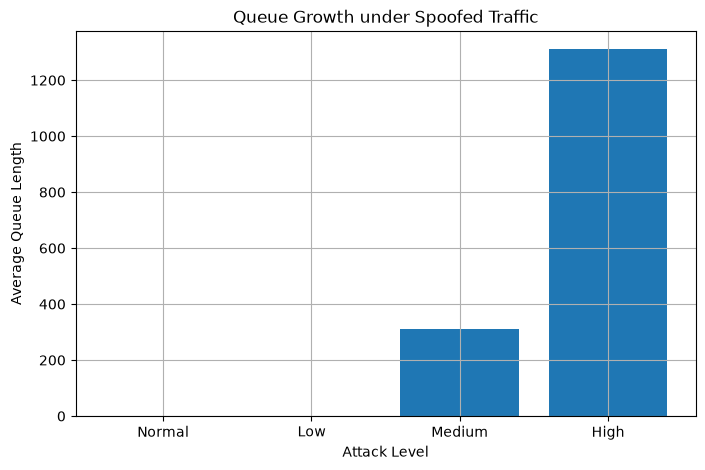

In [64]:
# Queue Length
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Queue_Packets"]
)

plt.xlabel("Attack Level")

plt.ylabel("Average Queue Length")

plt.title("Queue Growth under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_queue_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

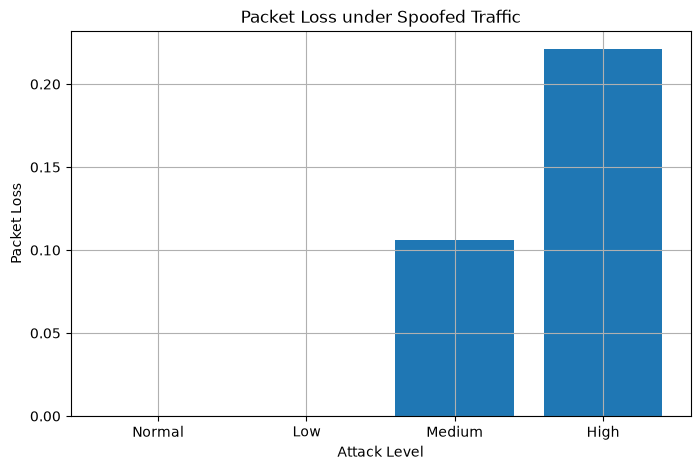

In [65]:
# Packet Loss
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Packet_Loss"]
)

plt.xlabel("Attack Level")

plt.ylabel("Packet Loss")

plt.title("Packet Loss under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_packet_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
# Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

# Import Sionna Modules
from sionna.phy.channel import AWGN
from sionna.phy.mapping import Mapper
from sionna.phy.mapping import Demapper

print("Modules Imported Successfully")

TensorFlow: 2.20.0
Sionna: 2.0.1
Modules Imported Successfully


In [67]:
# Simulation Parameters
NUM_BITS = 10000

SNR_dB = np.arange(0,21,2)

ber = []

# Generate Random Bits
bits = tf.random.uniform(
    [NUM_BITS],
    maxval=2,
    dtype=tf.int32
)

print(bits[:20])

tf.Tensor([0 1 1 1 1 1 1 1 0 0 1 0 1 1 0 0 0 0 0 1], shape=(20,), dtype=int32)


In [68]:
# BPSK Mapping
symbols = 2*tf.cast(bits,tf.float32)-1

print(symbols[:20])

tf.Tensor(
[-1.  1.  1.  1.  1.  1.  1.  1. -1. -1.  1. -1.  1.  1. -1. -1. -1. -1.
 -1.  1.], shape=(20,), dtype=float32)


In [69]:
print("SNR_dB:", SNR_dB)
print("Length of SNR_dB:", len(SNR_dB))

print("BER:", ber)
print("Length of BER:", len(ber))
print(ber)

SNR_dB: [ 0  2  4  6  8 10 12 14 16 18 20]
Length of SNR_dB: 11
BER: []
Length of BER: 0
[]


In [70]:
# AWGN Channel
ber = []
for snr in SNR_dB:

    sigma = np.sqrt(1/(2*10**(snr/10)))

    noise = sigma*tf.random.normal(symbols.shape)

    rx = symbols+noise

    detected=tf.cast(rx>0,tf.int32)

    errors=tf.reduce_sum(
        tf.cast(
            detected!=bits,
            tf.int32
        )
    )

    ber.append(errors.numpy()/NUM_BITS)

In [71]:
print(ber)
len(ber)

[np.float64(0.0775), np.float64(0.039), np.float64(0.0141), np.float64(0.0014), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


11

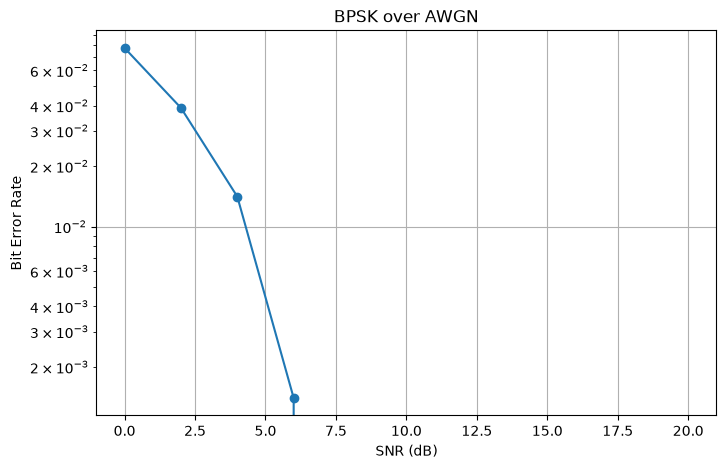

In [72]:
SNR_dB = np.arange(0,21,2)
# BER Curve
plt.figure(figsize=(8,5))

plt.semilogy(
    SNR_dB,
    ber,
    marker='o'
)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Bit Error Rate")

plt.title("BPSK over AWGN")

plt.savefig(
    "figures_step9_ber_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
import sionna

print(dir(sionna))
print("Sionna Version:", sionna.__version__)

['ModuleType', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'importlib', 'phy', 'pkgutil']
Sionna Version: 2.0.1


In [74]:
import pkgutil
import sionna

print("Available Sionna Modules\n")

for module in pkgutil.iter_modules(sionna.__path__):
    print(module.name)

Available Sionna Modules

phy
rt
sys


In [75]:
import sionna.phy

print(dir(sionna.phy))

['ALPHA_MAX', 'BOLTZMANN_CONSTANT', 'Block', 'DIELECTRIC_PERMITTIVITY_VACUUM', 'H', 'Object', 'PI', 'Precision', 'SPEED_OF_LIGHT', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'block', 'channel', 'config', 'constants', 'dtypes', 'fec', 'mapping', 'mimo', 'nr', 'object', 'ofdm', 'scipy', 'signal', 'utils']


In [76]:
import pkgutil
import sionna.phy

print("Available PHY Packages\n")

for module in pkgutil.iter_modules(sionna.phy.__path__):
    print(module.name)

Available PHY Packages

block
channel
config
constants
fec
mapping
mimo
nr
object
ofdm
signal
utils


In [77]:
import sionna.phy.channel

print(dir(sionna.phy.channel))

import sionna.phy.ofdm

print(dir(sionna.phy.ofdm))

import sionna.phy.channel as ch

print(dir(ch))

import sionna.phy.ofdm as ofdm

print(dir(ofdm))


['AWGN', 'ApplyFlatFadingChannel', 'ApplyOFDMChannel', 'ApplyTimeChannel', 'BinaryErasureChannel', 'BinaryMemorylessChannel', 'BinarySymmetricChannel', 'BinaryZChannel', 'CIRDataset', 'ChannelModel', 'DEFAULT_L_MIN', 'EDFA', 'FlatFadingChannel', 'GenerateFlatFadingChannel', 'GenerateOFDMChannel', 'GenerateTimeChannel', 'KroneckerModel', 'OFDMChannel', 'PerColumnModel', 'RayleighBlockFading', 'SSFM', 'SpatialCorrelation', 'TimeChannel', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'apply_ofdm_channel', 'apply_time_channel', 'awgn', 'channel_model', 'cir_dataset', 'cir_to_ofdm_channel', 'cir_to_time_channel', 'constants', 'deg_2_rad', 'discrete_channel', 'drop_uts_in_sector', 'exp_corr_mat', 'flat_fading_channel', 'gen_single_sector_topology', 'gen_single_sector_topology_interferers', 'generate_ofdm_channel', 'generate_time_channel', 'generate_uts_topology', 'ofdm_channel', 'one_ring_corr_mat', 'optical', 'rad_2_deg

In [78]:
# ======================================================
# STEP 10 - Sionna PHY Integration
# Small-Scale Fading
# ======================================================

import tensorflow as tf
import numpy as np

np.random.seed(42)
tf.random.set_seed(42)

num_users = len(user_positions)

In [79]:
# Rayleigh fading coefficient

# Real part
real = tf.random.normal([num_users], dtype=tf.float32)

# Imaginary part
imag = tf.random.normal([num_users], dtype=tf.float32)

# Create complex channel coefficients
h = tf.complex(real, imag) / tf.cast(tf.sqrt(2.0), tf.complex64)

print(h[:10])

tf.Tensor(
[ 0.23155521+5.9555773e-02j -0.59582645-6.0875088e-01j
  0.22587374+2.6737338e-01j -0.9952895 -3.6743204e-03j
 -1.6886133 -3.4968692e-01j -0.7348592 +4.3686414e-01j
 -0.39408705-2.3392540e-01j  0.38163048-9.7869278e-04j
  1.2016801 -2.9962525e-01j  0.204309  -9.8090470e-01j], shape=(10,), dtype=complex64)


In [80]:
# Channel Power Gain
channel_gain = tf.abs(h)**2

channel_gain = channel_gain.numpy()

print(channel_gain[:10])

[0.0571647  0.7255867  0.12250747 0.9906146  2.973696   0.7308683
 0.2100257  0.14564276 1.5338105  1.003916  ]


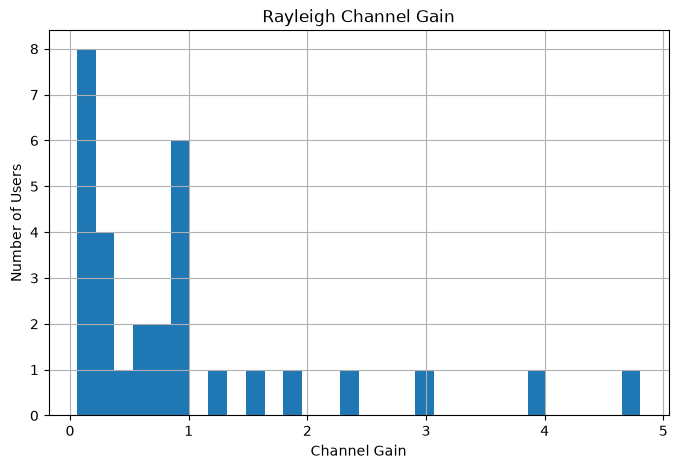

In [81]:
# Plot the Fading Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(channel_gain,
         bins=30)

plt.xlabel("Channel Gain")

plt.ylabel("Number of Users")

plt.title("Rayleigh Channel Gain")

plt.grid(True)

plt.savefig(
    "figures_step10_channel_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
received_power
channel_gain = channel_gain.reshape(-1, 1)

received_power_fading = received_power + 10*np.log10(channel_gain)

print(received_power_fading[:10])

[[-76.36013795 -78.94180563 -72.59422742]
 [-71.31812476 -60.12776491 -71.73905765]
 [-78.46710079 -80.74346586 -72.15858287]
 [-64.49068995 -63.54877462 -70.65937205]
 [-45.40667431 -63.40083265 -63.23271884]
 [-61.20967298 -71.73249721 -71.36010133]
 [-75.67605081 -79.30362392 -73.63546676]
 [-73.34141615 -77.44770013 -69.94724726]
 [-66.08922579 -70.14784647 -64.49912903]
 [-71.04710472 -63.3850331  -68.4707985 ]]


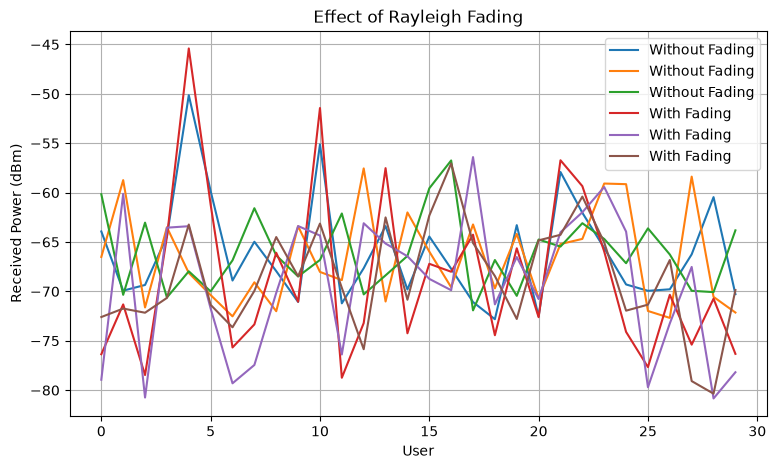

In [83]:
# Plot the Difference
plt.figure(figsize=(9,5))

plt.plot(received_power,
         label="Without Fading")

plt.plot(received_power_fading,
         label="With Fading")

plt.xlabel("User")

plt.ylabel("Received Power (dBm)")

plt.title("Effect of Rayleigh Fading")

plt.legend()

plt.grid(True)

plt.savefig(
    "figures_step10_received_power_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [84]:
# Recalculate SINR
received_power_mW = 10**(received_power_fading/10)

noise_power = 1e-10

sinr = received_power_mW / noise_power

sinr_dB = 10*np.log10(sinr)

print(sinr_dB[:10])

[[23.63986205 21.05819437 27.40577258]
 [28.68187524 39.87223509 28.26094235]
 [21.53289921 19.25653414 27.84141713]
 [35.50931005 36.45122538 29.34062795]
 [54.59332569 36.59916735 36.76728116]
 [38.79032702 28.26750279 28.63989867]
 [24.32394919 20.69637608 26.36453324]
 [26.65858385 22.55229987 30.05275274]
 [33.91077421 29.85215353 35.50087097]
 [28.95289528 36.6149669  31.5292015 ]]


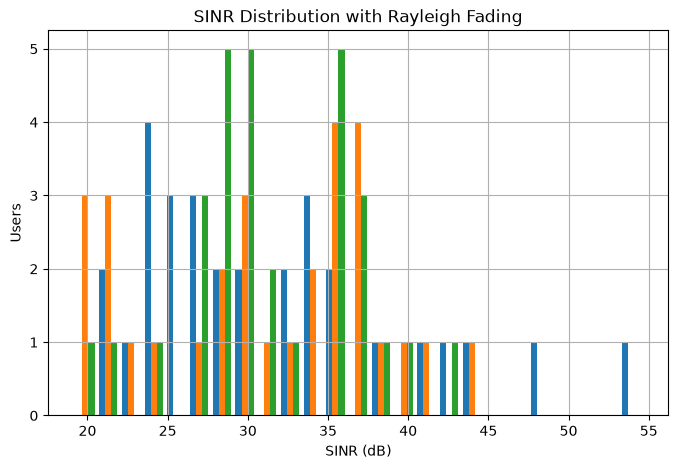

In [85]:
# Compare SINR
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=25)

plt.xlabel("SINR (dB)")

plt.ylabel("Users")

plt.title("SINR Distribution with Rayleigh Fading")

plt.grid(True)

plt.savefig(
    "figures_step10_sinr_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [86]:
# =====================================================
# STEP 11 - Beamforming
# =====================================================

beamforming_gain_dB = 6

print("Beamforming Gain:", beamforming_gain_dB, "dB")

received_power_beamforming = received_power_fading + beamforming_gain_dB

print(received_power_beamforming[:5])
print(received_power_fading.shape)

Beamforming Gain: 6 dB
[[-70.36013795 -72.94180563 -66.59422742]
 [-65.31812476 -54.12776491 -65.73905765]
 [-72.46710079 -74.74346586 -66.15858287]
 [-58.49068995 -57.54877462 -64.65937205]
 [-39.40667431 -57.40083265 -57.23271884]]
(30, 3)


In [87]:
# Calculate New SINR
received_power_mW = 10 ** (received_power_beamforming / 10)
# Assume:
noise_power_mW = 1e-10

sinr_beam = received_power_mW / noise_power_mW

sinr_beam_dB = 10 * np.log10(sinr_beam)

In [88]:
# Compare Average SINR
print("Average SINR without Beamforming:")

print(np.mean(sinr_dB))

print()

print("Average SINR with Beamforming:")

print(np.mean(sinr_beam_dB))

Average SINR without Beamforming:
31.177996228220415

Average SINR with Beamforming:
37.17799622822042


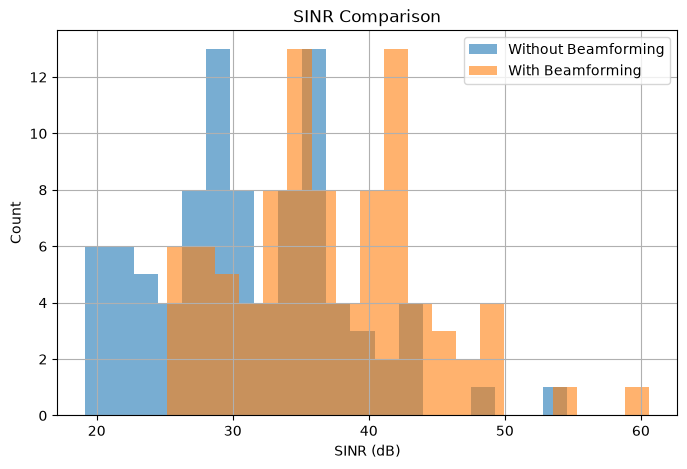

In [89]:
# Plot the Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    sinr_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="Without Beamforming"
)

plt.hist(
    sinr_beam_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="With Beamforming"
)

plt.xlabel("SINR (dB)")
plt.ylabel("Count")
plt.title("SINR Comparison")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_sinr_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [90]:
import numpy as np

# Check the shape first
print("Received power shape:", received_power_beamforming.shape)

# Assign each user to the BS with the highest received power
assignments_beamforming = np.argmax(
    received_power_beamforming,
    axis=1
)

print("User assignments:")
print(assignments_beamforming)

Received power shape: (30, 3)
User assignments:
[2 1 2 1 0 0 2 2 2 1 0 2 1 0 1 2 2 1 2 0 2 0 0 1 1 2 2 1 0 2]


In [91]:
# Count Users Per Base Station
num_bs = received_power_beamforming.shape[1]

users_per_bs = np.bincount(
    assignments_beamforming,
    minlength=num_bs
)

for bs in range(num_bs):
    print(f"BS {bs+1}: {users_per_bs[bs]} users")

BS 1: 8 users
BS 2: 9 users
BS 3: 13 users


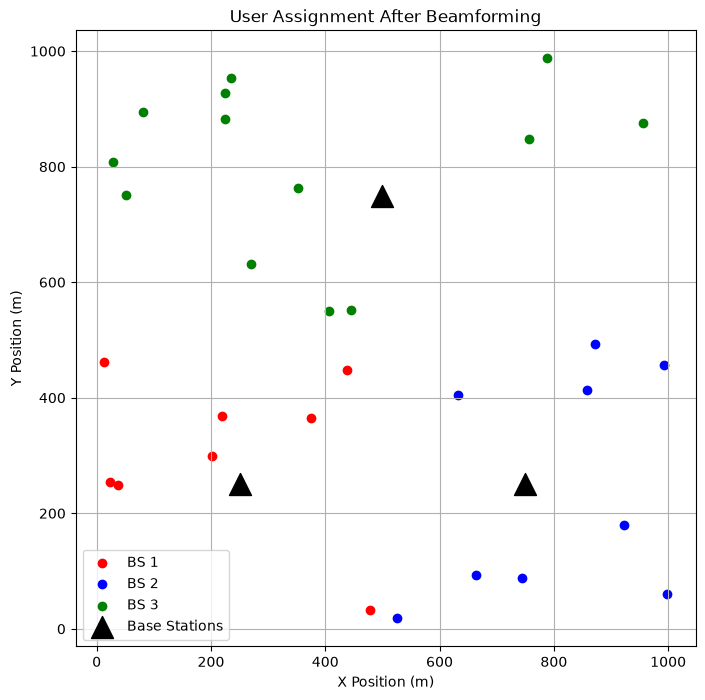

In [92]:
# Visualize User Assignment
colors = ["red", "blue", "green"]

plt.figure(figsize=(8,8))

for bs in range(num_bs):

    users = user_positions[
        assignments_beamforming == bs
    ]

    plt.scatter(
        users[:,0],
        users[:,1],
        color=colors[bs],
        label=f"BS {bs+1}"
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker="^",
    s=250,
    color="black",
    label="Base Stations"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("User Assignment After Beamforming")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_user_assignment_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [93]:
# =======================================================
# STEP 12 - Base Station Load Analysis and Visualization
# =======================================================

# STEP 12.1 - Base Station Load Analysis

num_bs = received_power_beamforming.shape[1]

# Number of users connected to each BS
users_per_bs = np.bincount(
    assignments_beamforming,
    minlength=num_bs
)

print("===== BASE STATION LOAD =====")

for bs in range(num_bs):
    print(f"BS {bs+1}: {users_per_bs[bs]} users")

print("\nTotal Users:", np.sum(users_per_bs))

===== BASE STATION LOAD =====
BS 1: 8 users
BS 2: 9 users
BS 3: 13 users

Total Users: 30


In [94]:
# STEP 12.2 - Load Percentage

load_percentage = (
    users_per_bs / np.sum(users_per_bs)
) * 100

print("===== BASE STATION LOAD PERCENTAGE =====")

for bs in range(num_bs):
    print(
        f"BS {bs+1}: "
        f"{load_percentage[bs]:.2f}% "
        f"({users_per_bs[bs]} users)"
    )

===== BASE STATION LOAD PERCENTAGE =====
BS 1: 26.67% (8 users)
BS 2: 30.00% (9 users)
BS 3: 43.33% (13 users)


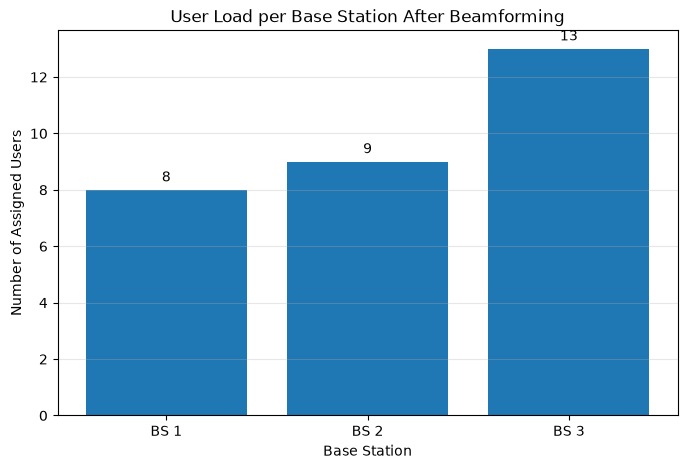

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# STEP 12.3 - Plot Base Station Load

bs_labels = [
    f"BS {i+1}"
    for i in range(num_bs)
]

plt.figure(figsize=(8, 5))

plt.bar(
    bs_labels,
    users_per_bs
)

plt.xlabel("Base Station")
plt.ylabel("Number of Assigned Users")
plt.title("User Load per Base Station After Beamforming")

# Add values above bars
for i, value in enumerate(users_per_bs):
    plt.text(
        i,
        value + 0.3,
        str(value),
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

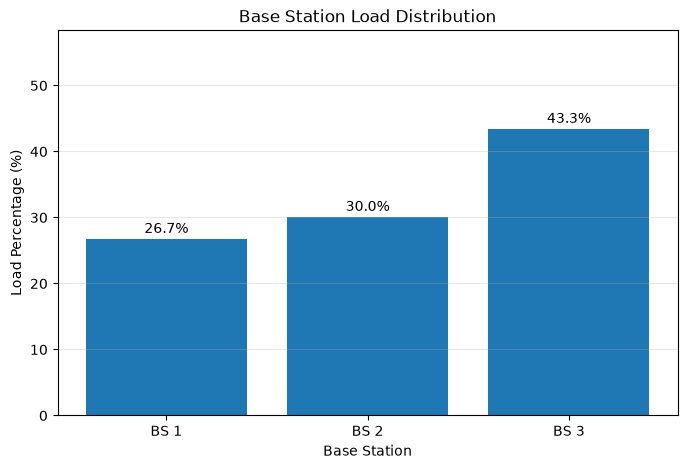

In [96]:
# STEP 12.4 - Base Station Load Percentage

plt.figure(figsize=(8, 5))

plt.bar(
    bs_labels,
    load_percentage
)

plt.xlabel("Base Station")
plt.ylabel("Load Percentage (%)")
plt.title("Base Station Load Distribution")

for i, value in enumerate(load_percentage):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(
    0,
    max(load_percentage) + 15
)

plt.grid(axis="y", alpha=0.3)

plt.show()

In [97]:
# ===================================================
# STEP 13 - Realistic Legitimate Traffic Generation
# ===================================================

# STEP 13.1 - Traffic Generation Setup

import numpy as np
import matplotlib.pyplot as plt

# Fixed seed for reproducible traffic generation
np.random.seed(42)

num_users = len(assignments_beamforming)

print("Number of users:", num_users)

Number of users: 30


In [98]:
# STEP 13.2 - Generate Realistic User Traffic

np.random.seed(100)

# Randomly assign traffic types
traffic_type = np.random.choice(
    ["Low", "Medium", "High"],
    size=num_users,
    p=[0.4, 0.4, 0.2]
)

# Create traffic demand in Mbps
user_traffic = np.zeros(num_users)

for i in range(num_users):

    if traffic_type[i] == "Low":
        user_traffic[i] = np.random.uniform(0.5, 2.0)

    elif traffic_type[i] == "Medium":
        user_traffic[i] = np.random.uniform(2.0, 8.0)

    elif traffic_type[i] == "High":
        user_traffic[i] = np.random.uniform(8.0, 20.0)

print("Traffic generated successfully.")
print("\nFirst 10 users:")

for i in range(min(10, num_users)):
    print(
        f"User {i+1}: "
        f"{traffic_type[i]} traffic, "
        f"{user_traffic[i]:.2f} Mbps"
    )

Traffic generated successfully.

First 10 users:
User 1: Medium traffic, 5.59 Mbps
User 2: Low traffic, 1.41 Mbps
User 3: Medium traffic, 2.63 Mbps
User 4: High traffic, 12.58 Mbps
User 5: Low traffic, 0.55 Mbps
User 6: Low traffic, 1.84 Mbps
User 7: Medium traffic, 7.89 Mbps
User 8: High traffic, 8.72 Mbps
User 9: Low traffic, 1.84 Mbps
User 10: Medium traffic, 5.46 Mbps


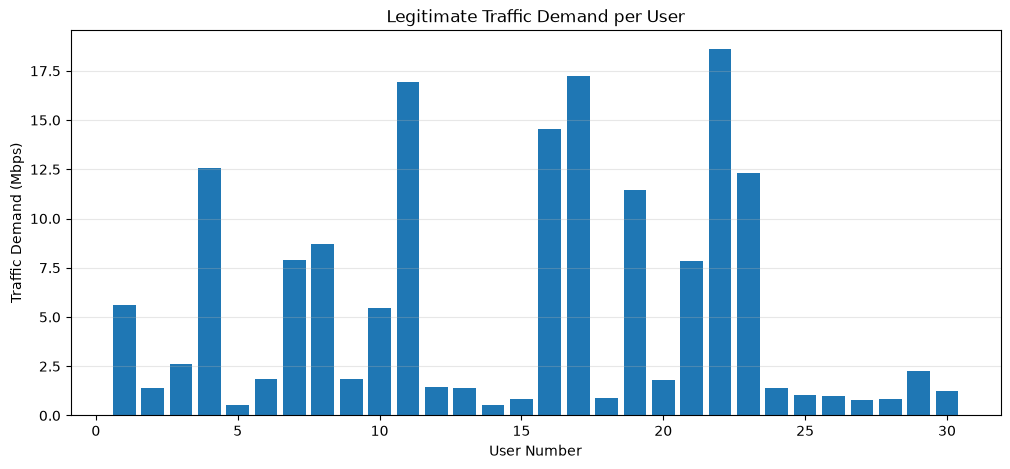

In [99]:
# STEP 13.3 - Plot Traffic Demand per User

plt.figure(figsize=(12, 5))

plt.bar(
    np.arange(1, num_users + 1),
    user_traffic
)

plt.xlabel("User Number")
plt.ylabel("Traffic Demand (Mbps)")
plt.title("Legitimate Traffic Demand per User")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [100]:
assignments_beamforming

# STEP 13.4 - Calculate Traffic Load per Base Station

traffic_per_bs = np.zeros(num_bs)

for bs in range(num_bs):

    # Get users assigned to this BS
    bs_users = (
        assignments_beamforming == bs
    )

    # Sum traffic from assigned users
    traffic_per_bs[bs] = np.sum(
        user_traffic[bs_users]
    )

print("===== LEGITIMATE TRAFFIC PER BASE STATION =====")

for bs in range(num_bs):

    print(
        f"BS {bs+1}: "
        f"{traffic_per_bs[bs]:.2f} Mbps"
    )

print(
    "\nTotal Network Traffic:",
    f"{np.sum(traffic_per_bs):.2f} Mbps"
)

===== LEGITIMATE TRAFFIC PER BASE STATION =====
BS 1: 54.81 Mbps
BS 2: 25.80 Mbps
BS 3: 82.19 Mbps

Total Network Traffic: 162.80 Mbps


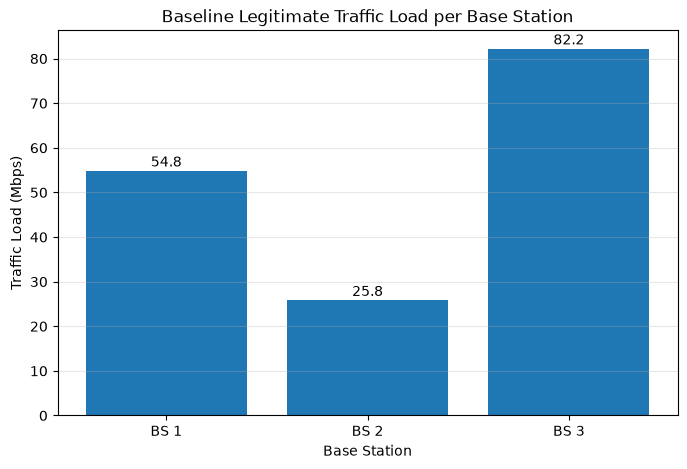

In [101]:
# STEP 13.5 - Visualize Traffic Load per Base Station

plt.figure(figsize=(8, 5))

plt.bar(
    bs_labels,
    traffic_per_bs
)

plt.xlabel("Base Station")
plt.ylabel("Traffic Load (Mbps)")
plt.title("Baseline Legitimate Traffic Load per Base Station")

# Add traffic values above bars
for i, value in enumerate(traffic_per_bs):

    plt.text(
        i,
        value + 1,
        f"{value:.1f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

In [102]:
# STEP 13.6 - User Traffic Summary

import pandas as pd

traffic_summary = pd.DataFrame({
    "User": np.arange(1, num_users + 1),
    "Traffic Type": traffic_type,
    "Traffic Demand (Mbps)": np.round(user_traffic, 2),
    "Assigned BS": assignments_beamforming + 1
})

traffic_summary

,User,Traffic Type,Traffic Demand (Mbps),Assigned BS
0,1,Medium,5.59,3
1,2,Low,1.41,2
2,3,Medium,2.63,3
3,4,High,12.58,2
4,5,Low,0.55,1
5,6,Low,1.84,1
6,7,Medium,7.89,3
7,8,High,8.72,3
8,9,Low,1.84,3
9,10,Medium,5.46,2


In [103]:
# ===================================================
# STEP 14 - Spoofed Traffic Attack Modelling
# ===================================================

# STEP 14.1 - Check Baseline Legitimate Traffic

print("===== BASELINE LEGITIMATE TRAFFIC =====")

for bs in range(num_bs):
    print(f"BS {bs+1}: {traffic_per_bs[bs]:.2f} Mbps")

total_legitimate_traffic = np.sum(traffic_per_bs)

print(f"\nTotal Legitimate Traffic: {total_legitimate_traffic:.2f} Mbps")

===== BASELINE LEGITIMATE TRAFFIC =====
BS 1: 54.81 Mbps
BS 2: 25.80 Mbps
BS 3: 82.19 Mbps

Total Legitimate Traffic: 162.80 Mbps


In [104]:
# STEP 14.2 - Define Spoofed Traffic Attack Levels

attack_levels = {
    "Normal": 0.00,
    "Low Attack": 0.25,
    "Medium Attack": 0.50,
    "High Attack": 1.00
}

print("===== ATTACK SCENARIOS =====")

for scenario, level in attack_levels.items():
    print(f"{scenario}: {level*100:.0f}% additional spoofed traffic")

===== ATTACK SCENARIOS =====
Normal: 0% additional spoofed traffic
Low Attack: 25% additional spoofed traffic
Medium Attack: 50% additional spoofed traffic
High Attack: 100% additional spoofed traffic


In [105]:
# STEP 14.3 - Generate Spoofed Traffic Per Base Station

np.random.seed(200)

spoofed_traffic_results = {}

for scenario, attack_level in attack_levels.items():

    # Calculate total spoofed traffic
    total_spoofed_traffic = (
        total_legitimate_traffic * attack_level
    )

    # Randomly distribute spoofed traffic among base stations
    distribution = np.random.dirichlet(
        np.ones(num_bs)
    )

    spoofed_traffic_per_bs = (
        total_spoofed_traffic * distribution
    )

    spoofed_traffic_results[scenario] = spoofed_traffic_per_bs

    print(f"\n{scenario}")

    for bs in range(num_bs):
        print(
            f"BS {bs+1}: "
            f"{spoofed_traffic_per_bs[bs]:.2f} Mbps spoofed traffic"
        )


Normal
BS 1: 0.00 Mbps spoofed traffic
BS 2: 0.00 Mbps spoofed traffic
BS 3: 0.00 Mbps spoofed traffic

Low Attack
BS 1: 11.34 Mbps spoofed traffic
BS 2: 29.30 Mbps spoofed traffic
BS 3: 0.06 Mbps spoofed traffic

Medium Attack
BS 1: 10.42 Mbps spoofed traffic
BS 2: 56.64 Mbps spoofed traffic
BS 3: 14.34 Mbps spoofed traffic

High Attack
BS 1: 63.34 Mbps spoofed traffic
BS 2: 31.94 Mbps spoofed traffic
BS 3: 67.52 Mbps spoofed traffic


In [106]:
# STEP 14.4 - Calculate Total Traffic During Each Attack

total_traffic_results = {}

for scenario in attack_levels:

    spoofed_traffic = spoofed_traffic_results[scenario]

    total_traffic = (
        traffic_per_bs +
        spoofed_traffic
    )

    total_traffic_results[scenario] = total_traffic

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):
        print(
            f"BS {bs+1}: "
            f"{total_traffic[bs]:.2f} Mbps"
        )

    print(
        f"Total Network Traffic: "
        f"{np.sum(total_traffic):.2f} Mbps"
    )


===== NORMAL =====
BS 1: 54.81 Mbps
BS 2: 25.80 Mbps
BS 3: 82.19 Mbps
Total Network Traffic: 162.80 Mbps

===== LOW ATTACK =====
BS 1: 66.15 Mbps
BS 2: 55.10 Mbps
BS 3: 82.25 Mbps
Total Network Traffic: 203.50 Mbps

===== MEDIUM ATTACK =====
BS 1: 65.23 Mbps
BS 2: 82.44 Mbps
BS 3: 96.54 Mbps
Total Network Traffic: 244.21 Mbps

===== HIGH ATTACK =====
BS 1: 118.16 Mbps
BS 2: 57.74 Mbps
BS 3: 149.71 Mbps
Total Network Traffic: 325.61 Mbps


In [107]:
# STEP 14.5 - Create Attack Scenario Results Table

import pandas as pd

attack_summary = pd.DataFrame({
    "Scenario": list(attack_levels.keys()),
    "BS 1 Traffic (Mbps)": [
        total_traffic_results[s][0]
        for s in attack_levels
    ],
    "BS 2 Traffic (Mbps)": [
        total_traffic_results[s][1]
        for s in attack_levels
    ],
    "BS 3 Traffic (Mbps)": [
        total_traffic_results[s][2]
        for s in attack_levels
    ],
    "Total Network Traffic (Mbps)": [
        np.sum(total_traffic_results[s])
        for s in attack_levels
    ]
})

attack_summary = attack_summary.round(2)

attack_summary

,Scenario,BS 1 Traffic (Mbps),BS 2 Traffic (Mbps),BS 3 Traffic (Mbps),Total Network Traffic (Mbps)
0,Normal,54.81,25.80,82.19,162.80
1,Low Attack,66.15,55.10,82.25,203.50
2,Medium Attack,65.23,82.44,96.54,244.21
3,High Attack,118.16,57.74,149.71,325.61


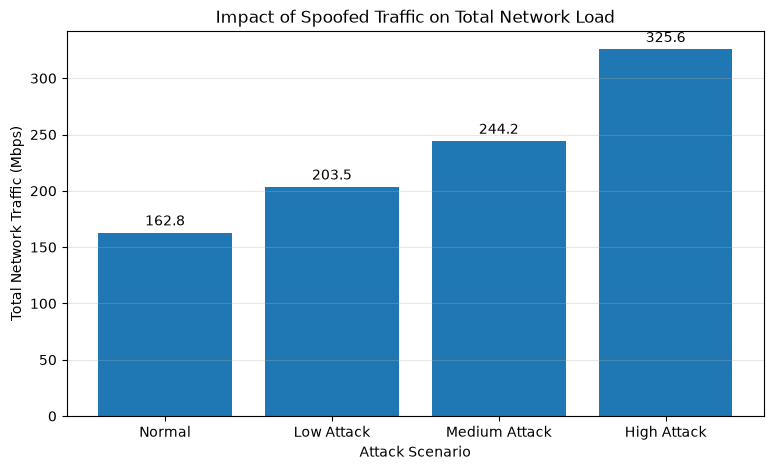

In [108]:
# STEP 14.6 - Compare Total Network Traffic

scenario_names = list(attack_levels.keys())

total_network_traffic = [
    np.sum(total_traffic_results[scenario])
    for scenario in scenario_names
]

plt.figure(figsize=(9, 5))

plt.bar(
    scenario_names,
    total_network_traffic
)

plt.xlabel("Attack Scenario")
plt.ylabel("Total Network Traffic (Mbps)")
plt.title("Impact of Spoofed Traffic on Total Network Load")

for i, value in enumerate(total_network_traffic):
    plt.text(
        i,
        value + max(total_network_traffic) * 0.02,
        f"{value:.1f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

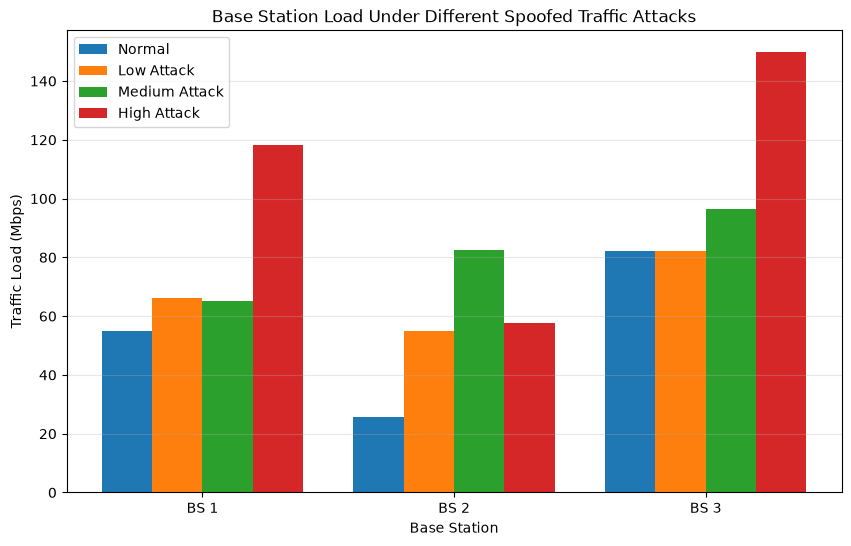

In [110]:
# STEP 14.7 - Compare Base Station Traffic Under Different Attacks

x = np.arange(num_bs)

width = 0.2

plt.figure(figsize=(10, 6))

for i, scenario in enumerate(scenario_names):

    plt.bar(
        x + i * width,
        total_traffic_results[scenario],
        width,
        label=scenario
    )

plt.xticks(
    x + width * 1.5,
    [f"BS {i+1}" for i in range(num_bs)]
)

plt.xlabel("Base Station")
plt.ylabel("Traffic Load (Mbps)")
plt.title("Base Station Load Under Different Spoofed Traffic Attacks")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

In [111]:
# ========================================================
# STEP 15 - Base Station Capacity and Congestion Analysis
# ========================================================
# STEP 15.1 - Define Base Station Capacity

bs_capacity = np.full(
    num_bs,
    100.0
)

print("===== BASE STATION CAPACITY =====")

for bs in range(num_bs):
    print(
        f"BS {bs+1}: "
        f"{bs_capacity[bs]:.1f} Mbps"
    )

===== BASE STATION CAPACITY =====
BS 1: 100.0 Mbps
BS 2: 100.0 Mbps
BS 3: 100.0 Mbps


In [112]:
# STEP 15.2 - Calculate BS Capacity Utilization

utilization_results = {}

for scenario in scenario_names:

    utilization = (
        total_traffic_results[scenario]
        / bs_capacity
    ) * 100

    utilization_results[scenario] = utilization

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):

        print(
            f"BS {bs+1}: "
            f"{utilization[bs]:.2f}% utilization"
        )


===== NORMAL =====
BS 1: 54.81% utilization
BS 2: 25.80% utilization
BS 3: 82.19% utilization

===== LOW ATTACK =====
BS 1: 66.15% utilization
BS 2: 55.10% utilization
BS 3: 82.25% utilization

===== MEDIUM ATTACK =====
BS 1: 65.23% utilization
BS 2: 82.44% utilization
BS 3: 96.54% utilization

===== HIGH ATTACK =====
BS 1: 118.16% utilization
BS 2: 57.74% utilization
BS 3: 149.71% utilization


In [113]:
# STEP 15.3 - Detect Congested Base Stations

congestion_results = {}

for scenario in scenario_names:

    utilization = utilization_results[scenario]

    congestion_status = utilization > 100

    congestion_results[scenario] = congestion_status

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):

        if congestion_status[bs]:

            print(
                f"BS {bs+1}: CONGESTED "
                f"({utilization[bs]:.1f}%)"
            )

        else:

            print(
                f"BS {bs+1}: Normal "
                f"({utilization[bs]:.1f}%)"
            )


===== NORMAL =====
BS 1: Normal (54.8%)
BS 2: Normal (25.8%)
BS 3: Normal (82.2%)

===== LOW ATTACK =====
BS 1: Normal (66.2%)
BS 2: Normal (55.1%)
BS 3: Normal (82.2%)

===== MEDIUM ATTACK =====
BS 1: Normal (65.2%)
BS 2: Normal (82.4%)
BS 3: Normal (96.5%)

===== HIGH ATTACK =====
BS 1: CONGESTED (118.2%)
BS 2: Normal (57.7%)
BS 3: CONGESTED (149.7%)


In [114]:
# STEP 15.4 - Calculate Excess Traffic

excess_traffic_results = {}

for scenario in scenario_names:

    excess_traffic = np.maximum(
        total_traffic_results[scenario]
        - bs_capacity,
        0
    )

    excess_traffic_results[scenario] = excess_traffic

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):

        print(
            f"BS {bs+1}: "
            f"{excess_traffic[bs]:.2f} Mbps excess traffic"
        )


===== NORMAL =====
BS 1: 0.00 Mbps excess traffic
BS 2: 0.00 Mbps excess traffic
BS 3: 0.00 Mbps excess traffic

===== LOW ATTACK =====
BS 1: 0.00 Mbps excess traffic
BS 2: 0.00 Mbps excess traffic
BS 3: 0.00 Mbps excess traffic

===== MEDIUM ATTACK =====
BS 1: 0.00 Mbps excess traffic
BS 2: 0.00 Mbps excess traffic
BS 3: 0.00 Mbps excess traffic

===== HIGH ATTACK =====
BS 1: 18.16 Mbps excess traffic
BS 2: 0.00 Mbps excess traffic
BS 3: 49.71 Mbps excess traffic


In [115]:
# STEP 15.5 - Calculate Available Capacity

available_capacity_results = {}

for scenario in scenario_names:

    available_capacity = np.maximum(
        bs_capacity -
        total_traffic_results[scenario],
        0
    )

    available_capacity_results[scenario] = available_capacity

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):

        print(
            f"BS {bs+1}: "
            f"{available_capacity[bs]:.2f} Mbps available"
        )


===== NORMAL =====
BS 1: 45.19 Mbps available
BS 2: 74.20 Mbps available
BS 3: 17.81 Mbps available

===== LOW ATTACK =====
BS 1: 33.85 Mbps available
BS 2: 44.90 Mbps available
BS 3: 17.75 Mbps available

===== MEDIUM ATTACK =====
BS 1: 34.77 Mbps available
BS 2: 17.56 Mbps available
BS 3: 3.46 Mbps available

===== HIGH ATTACK =====
BS 1: 0.00 Mbps available
BS 2: 42.26 Mbps available
BS 3: 0.00 Mbps available


In [116]:
# STEP 15.6 - Create Capacity Summary Table

capacity_summary_list = []

for scenario in scenario_names:

    for bs in range(num_bs):

        load = total_traffic_results[scenario][bs]

        utilization = utilization_results[scenario][bs]

        excess = excess_traffic_results[scenario][bs]

        available = available_capacity_results[scenario][bs]

        if utilization < 70:
            status = "Normal"

        elif utilization < 90:
            status = "High Load"

        elif utilization <= 100:
            status = "Critical"

        else:
            status = "Congested"

        capacity_summary_list.append({
            "Scenario": scenario,
            "Base Station": f"BS {bs+1}",
            "Traffic Load (Mbps)": round(load, 2),
            "Capacity (Mbps)": round(bs_capacity[bs], 2),
            "Utilization (%)": round(utilization, 2),
            "Available Capacity (Mbps)": round(available, 2),
            "Excess Traffic (Mbps)": round(excess, 2),
            "Status": status
        })

capacity_summary = pd.DataFrame(
    capacity_summary_list
)

capacity_summary

,Scenario,Base Station,Traffic Load (Mbps),Capacity (Mbps),Utilization (%),Available Capacity (Mbps),Excess Traffic (Mbps),Status
0,Normal,BS 1,54.81,100.0,54.81,45.19,0.00,Normal
1,Normal,BS 2,25.80,100.0,25.80,74.20,0.00,Normal
2,Normal,BS 3,82.19,100.0,82.19,17.81,0.00,High Load
3,Low Attack,BS 1,66.15,100.0,66.15,33.85,0.00,Normal
4,Low Attack,BS 2,55.10,100.0,55.10,44.90,0.00,Normal
5,Low Attack,BS 3,82.25,100.0,82.25,17.75,0.00,High Load
6,Medium Attack,BS 1,65.23,100.0,65.23,34.77,0.00,Normal
7,Medium Attack,BS 2,82.44,100.0,82.44,17.56,0.00,High Load
8,Medium Attack,BS 3,96.54,100.0,96.54,3.46,0.00,Critical
9,High Attack,BS 1,118.16,100.0,118.16,0.00,18.16,Congested


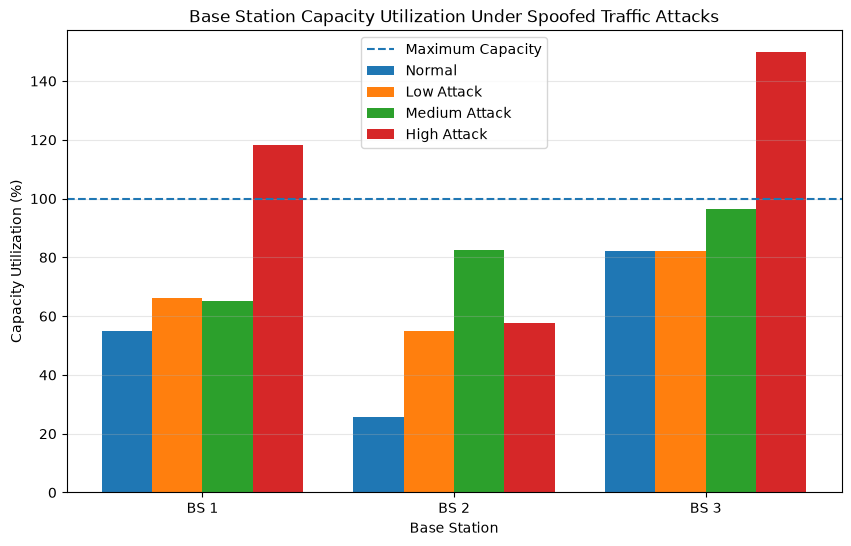

In [117]:
# STEP 15.7 - Plot BS Capacity Utilization

x = np.arange(num_bs)
width = 0.2

plt.figure(figsize=(10, 6))

for i, scenario in enumerate(scenario_names):

    plt.bar(
        x + i * width,
        utilization_results[scenario],
        width,
        label=scenario
    )

# Capacity limit line
plt.axhline(
    y=100,
    linestyle="--",
    label="Maximum Capacity"
)

plt.xticks(
    x + width * 1.5,
    [f"BS {i+1}" for i in range(num_bs)]
)

plt.xlabel("Base Station")
plt.ylabel("Capacity Utilization (%)")
plt.title(
    "Base Station Capacity Utilization Under Spoofed Traffic Attacks"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

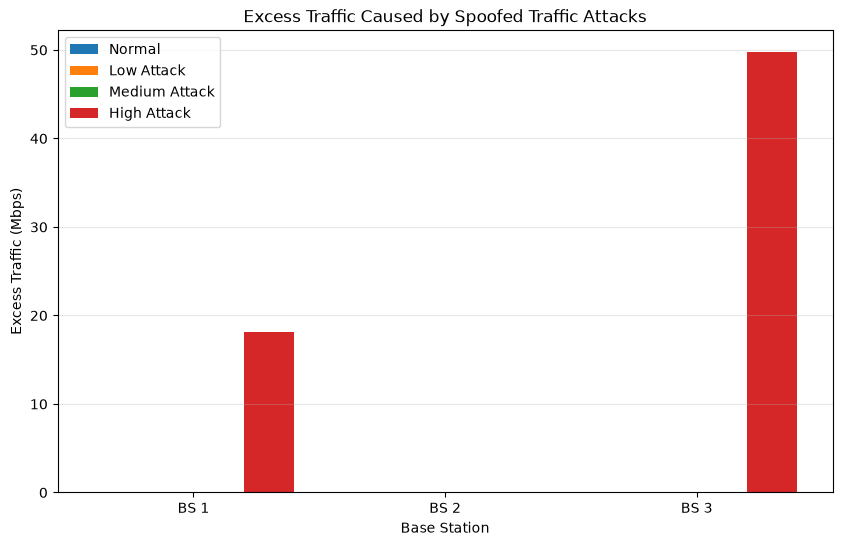

In [118]:
# STEP 15.8 - Plot Excess Traffic

plt.figure(figsize=(10, 6))

for i, scenario in enumerate(scenario_names):

    plt.bar(
        x + i * width,
        excess_traffic_results[scenario],
        width,
        label=scenario
    )

plt.xticks(
    x + width * 1.5,
    [f"BS {i+1}" for i in range(num_bs)]
)

plt.xlabel("Base Station")
plt.ylabel("Excess Traffic (Mbps)")
plt.title(
    "Excess Traffic Caused by Spoofed Traffic Attacks"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [119]:
# ==================================
# STEP 16 - QoS Impact Assessment
# ==================================
# STEP 16.1 - Calculate Achieved Throughput

throughput_results = {}

for scenario in scenario_names:

    achieved_throughput = np.minimum(
        total_traffic_results[scenario],
        bs_capacity
    )

    throughput_results[scenario] = achieved_throughput

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):

        print(
            f"BS {bs+1}: "
            f"{achieved_throughput[bs]:.2f} Mbps"
        )

    print(
        f"Total Achieved Throughput: "
        f"{np.sum(achieved_throughput):.2f} Mbps"
    )


===== NORMAL =====
BS 1: 54.81 Mbps
BS 2: 25.80 Mbps
BS 3: 82.19 Mbps
Total Achieved Throughput: 162.80 Mbps

===== LOW ATTACK =====
BS 1: 66.15 Mbps
BS 2: 55.10 Mbps
BS 3: 82.25 Mbps
Total Achieved Throughput: 203.50 Mbps

===== MEDIUM ATTACK =====
BS 1: 65.23 Mbps
BS 2: 82.44 Mbps
BS 3: 96.54 Mbps
Total Achieved Throughput: 244.21 Mbps

===== HIGH ATTACK =====
BS 1: 100.00 Mbps
BS 2: 57.74 Mbps
BS 3: 100.00 Mbps
Total Achieved Throughput: 257.74 Mbps


In [120]:
# STEP 16.2 - Calculate Throughput Degradation

normal_total_throughput = np.sum(
    throughput_results["Normal"]
)

throughput_degradation_results = {}

for scenario in scenario_names:

    current_throughput = np.sum(
        throughput_results[scenario]
    )

    degradation = (
        (normal_total_throughput - current_throughput)
        / normal_total_throughput
    ) * 100

    # Prevent negative degradation
    degradation = max(degradation, 0)

    throughput_degradation_results[scenario] = degradation

    print(
        f"{scenario}: "
        f"{degradation:.2f}% throughput degradation"
    )

Normal: 0.00% throughput degradation
Low Attack: 0.00% throughput degradation
Medium Attack: 0.00% throughput degradation
High Attack: 0.00% throughput degradation


In [121]:
# STEP 16.3 - Calculate Packet Loss Rate

packet_loss_results = {}

for scenario in scenario_names:

    traffic_load = total_traffic_results[scenario]

    excess_traffic = excess_traffic_results[scenario]

    packet_loss = (
        excess_traffic /
        np.maximum(traffic_load, 0.001)
    ) * 100

    packet_loss_results[scenario] = packet_loss

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):

        print(
            f"BS {bs+1}: "
            f"{packet_loss[bs]:.2f}% packet loss"
        )


===== NORMAL =====
BS 1: 0.00% packet loss
BS 2: 0.00% packet loss
BS 3: 0.00% packet loss

===== LOW ATTACK =====
BS 1: 0.00% packet loss
BS 2: 0.00% packet loss
BS 3: 0.00% packet loss

===== MEDIUM ATTACK =====
BS 1: 0.00% packet loss
BS 2: 0.00% packet loss
BS 3: 0.00% packet loss

===== HIGH ATTACK =====
BS 1: 15.37% packet loss
BS 2: 0.00% packet loss
BS 3: 33.21% packet loss


In [122]:
# STEP 16.4 - Calculate Average Packet Loss

average_packet_loss_results = {}

for scenario in scenario_names:

    average_loss = np.mean(
        packet_loss_results[scenario]
    )

    average_packet_loss_results[scenario] = average_loss

    print(
        f"{scenario}: "
        f"{average_loss:.2f}% average packet loss"
    )

Normal: 0.00% average packet loss
Low Attack: 0.00% average packet loss
Medium Attack: 0.00% average packet loss
High Attack: 16.19% average packet loss


In [123]:
# STEP 16.5 - Calculate Latency Based on Utilization

base_latency = 10.0  # milliseconds

latency_results = {}

for scenario in scenario_names:

    utilization = utilization_results[scenario]

    # Avoid division by zero
    safe_utilization = np.minimum(
        utilization,
        99
    )

    latency = (
        base_latency /
        (1 - safe_utilization / 100)
    )

    # Apply congestion penalty
    congestion = utilization >= 100

    latency[congestion] = (
        base_latency *
        (1 + utilization[congestion] / 50)
    )

    latency_results[scenario] = latency

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):

        print(
            f"BS {bs+1}: "
            f"{latency[bs]:.2f} ms"
        )


===== NORMAL =====
BS 1: 22.13 ms
BS 2: 13.48 ms
BS 3: 56.15 ms

===== LOW ATTACK =====
BS 1: 29.54 ms
BS 2: 22.27 ms
BS 3: 56.34 ms

===== MEDIUM ATTACK =====
BS 1: 28.76 ms
BS 2: 56.95 ms
BS 3: 288.68 ms

===== HIGH ATTACK =====
BS 1: 33.63 ms
BS 2: 23.66 ms
BS 3: 39.94 ms


In [124]:
# STEP 16.6 - Calculate Average Latency

average_latency_results = {}

for scenario in scenario_names:

    average_latency = np.mean(
        latency_results[scenario]
    )

    average_latency_results[scenario] = average_latency

    print(
        f"{scenario}: "
        f"{average_latency:.2f} ms"
    )

Normal: 30.59 ms
Low Attack: 36.05 ms
Medium Attack: 124.80 ms
High Attack: 32.41 ms


In [125]:
# STEP 16.7 - Create QoS Summary Table

qos_summary = pd.DataFrame({

    "Scenario": scenario_names,

    "Traffic Demand (Mbps)": [
        np.sum(total_traffic_results[s])
        for s in scenario_names
    ],

    "Achieved Throughput (Mbps)": [
        np.sum(throughput_results[s])
        for s in scenario_names
    ],

    "Throughput Degradation (%)": [
        throughput_degradation_results[s]
        for s in scenario_names
    ],

    "Average Latency (ms)": [
        average_latency_results[s]
        for s in scenario_names
    ],

    "Average Packet Loss (%)": [
        average_packet_loss_results[s]
        for s in scenario_names
    ]
})

qos_summary = qos_summary.round(2)

qos_summary

,Scenario,Traffic Demand (Mbps),Achieved Throughput (Mbps),Throughput Degradation (%),Average Latency (ms),Average Packet Loss (%)
0,Normal,162.80,162.80,0.0,30.59,0.00
1,Low Attack,203.50,203.50,0.0,36.05,0.00
2,Medium Attack,244.21,244.21,0.0,124.80,0.00
3,High Attack,325.61,257.74,0.0,32.41,16.19


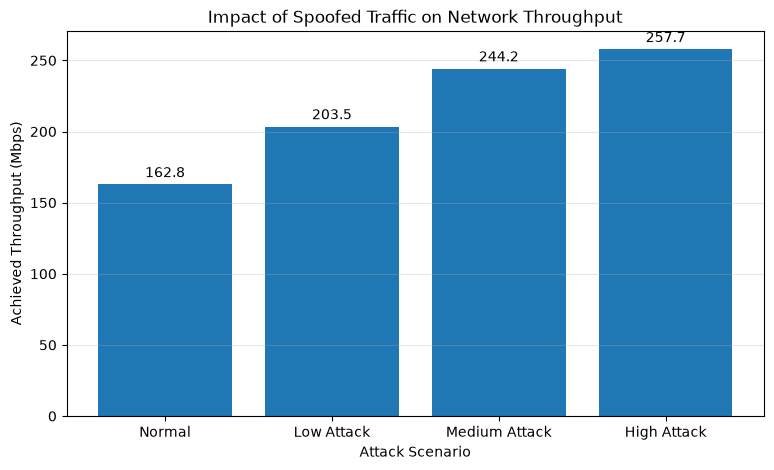

In [126]:
# STEP 16.8 - Plot Total Achieved Throughput

total_throughput = [
    np.sum(throughput_results[s])
    for s in scenario_names
]

plt.figure(figsize=(9, 5))

plt.bar(
    scenario_names,
    total_throughput
)

plt.xlabel("Attack Scenario")
plt.ylabel("Achieved Throughput (Mbps)")
plt.title(
    "Impact of Spoofed Traffic on Network Throughput"
)

plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(total_throughput):

    plt.text(
        i,
        value + max(total_throughput) * 0.02,
        f"{value:.1f}",
        ha="center"
    )

plt.show()

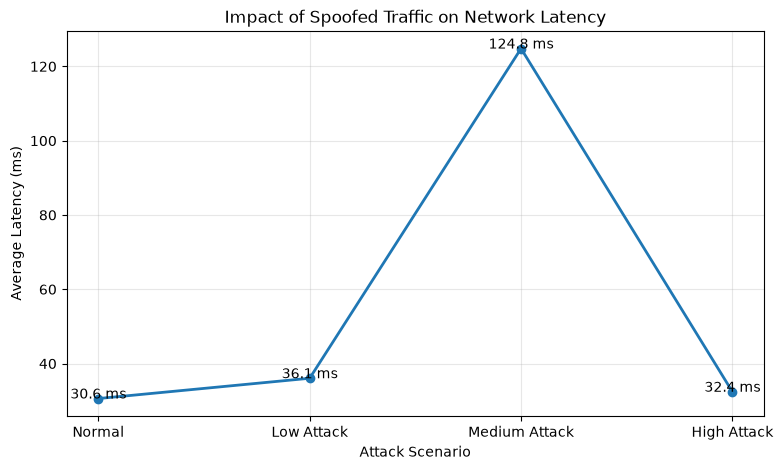

In [127]:
# STEP 16.9 - Plot Average Network Latency

average_latency = [
    average_latency_results[s]
    for s in scenario_names
]

plt.figure(figsize=(9, 5))

plt.plot(
    scenario_names,
    average_latency,
    marker="o",
    linewidth=2
)

plt.xlabel("Attack Scenario")
plt.ylabel("Average Latency (ms)")
plt.title(
    "Impact of Spoofed Traffic on Network Latency"
)

plt.grid(True, alpha=0.3)

for i, value in enumerate(average_latency):

    plt.text(
        i,
        value,
        f"{value:.1f} ms",
        ha="center"
    )

plt.show()

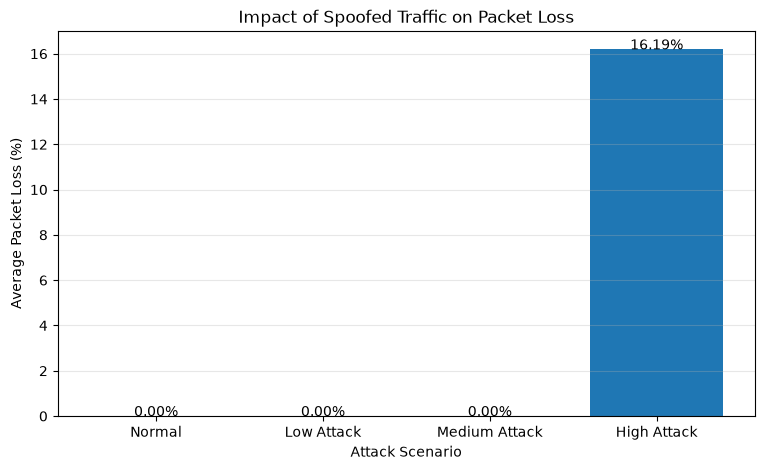

In [128]:
# STEP 16.10 - Plot Average Packet Loss

average_packet_loss = [
    average_packet_loss_results[s]
    for s in scenario_names
]

plt.figure(figsize=(9, 5))

plt.bar(
    scenario_names,
    average_packet_loss
)

plt.xlabel("Attack Scenario")
plt.ylabel("Average Packet Loss (%)")
plt.title(
    "Impact of Spoofed Traffic on Packet Loss"
)

plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(average_packet_loss):

    plt.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [129]:
# ==========================================================
# STEP 17 - User Reassignment Under Spoofed Traffic Attacks
# ==========================================================
# STEP 17.1 - Save Original User Assignment

original_assignments = assignments_beamforming.copy()

print("Original assignments saved successfully.")

for user in range(min(10, num_users)):
    print(
        f"User {user+1} → "
        f"BS {original_assignments[user] + 1}"
    )

Original assignments saved successfully.
User 1 → BS 3
User 2 → BS 2
User 3 → BS 3
User 4 → BS 2
User 5 → BS 1
User 6 → BS 1
User 7 → BS 3
User 8 → BS 3
User 9 → BS 3
User 10 → BS 2


In [130]:
# STEP 17.2 - Load-Aware User Reassignment Function

def reassign_users(
    initial_assignments,
    user_traffic,
    received_power,
    initial_load,
    bs_capacity
):

    # Copy original assignments
    new_assignments = initial_assignments.copy()

    # Copy current traffic load
    current_load = initial_load.copy()

    num_users = len(initial_assignments)
    num_bs = len(bs_capacity)

    reassigned_users = []

    # Find overloaded base stations
    overloaded_bs = np.where(
        current_load > bs_capacity
    )[0]

    print("Overloaded Base Stations:", overloaded_bs + 1)

    # Process each overloaded BS
    for overloaded in overloaded_bs:

        # Find users currently connected to this BS
        users_on_bs = np.where(
            new_assignments == overloaded
        )[0]

        # Sort users by traffic demand
        # Larger traffic users are considered first
        users_sorted = users_on_bs[
            np.argsort(user_traffic[users_on_bs])[::-1]
        ]

        for user in users_sorted:

            # Check if overload is resolved
            if current_load[overloaded] <= bs_capacity[overloaded]:
                break

            # Get all candidate BSs except current BS
            candidate_bs = [
                bs for bs in range(num_bs)
                if bs != overloaded
            ]

            # Sort candidate BSs based on received power
            candidate_bs = sorted(
                candidate_bs,
                key=lambda bs: received_power[user, bs],
                reverse=True
            )

            # Try each candidate BS
            for target_bs in candidate_bs:

                # Check whether target BS has enough available capacity
                if (
                    current_load[target_bs]
                    + user_traffic[user]
                    <= bs_capacity[target_bs]
                ):

                    # Move the user
                    new_assignments[user] = target_bs

                    # Update loads
                    current_load[overloaded] -= user_traffic[user]

                    current_load[target_bs] += user_traffic[user]

                    # Save reassignment information
                    reassigned_users.append({
                        "User": user + 1,
                        "From BS": overloaded + 1,
                        "To BS": target_bs + 1,
                        "Traffic (Mbps)": user_traffic[user]
                    })

                    break

    return (
        new_assignments,
        current_load,
        reassigned_users
    )

In [131]:
# STEP 17.3 - Apply User Reassignment

reassignment_results = {}

for scenario in scenario_names:

    print("\n" + "=" * 50)
    print(f"SCENARIO: {scenario.upper()}")
    print("=" * 50)

    # Original traffic load including spoofed traffic
    initial_load = total_traffic_results[scenario].copy()

    (
        new_assignments,
        new_load,
        reassigned_users
    ) = reassign_users(
        original_assignments,
        user_traffic,
        received_power_beamforming,
        initial_load,
        bs_capacity
    )

    reassignment_results[scenario] = {
        "assignments": new_assignments,
        "load": new_load,
        "reassigned_users": reassigned_users
    }

    print(
        f"\nNumber of reassigned users: "
        f"{len(reassigned_users)}"
    )


SCENARIO: NORMAL
Overloaded Base Stations: []

Number of reassigned users: 0

SCENARIO: LOW ATTACK
Overloaded Base Stations: []

Number of reassigned users: 0

SCENARIO: MEDIUM ATTACK
Overloaded Base Stations: []

Number of reassigned users: 0

SCENARIO: HIGH ATTACK
Overloaded Base Stations: [1 3]

Number of reassigned users: 4


In [132]:
# STEP 17.4 - Display Reassignment Details

for scenario in scenario_names:

    reassigned_users = (
        reassignment_results[scenario]
        ["reassigned_users"]
    )

    print("\n" + "=" * 50)
    print(scenario.upper())
    print("=" * 50)

    if len(reassigned_users) == 0:

        print("No users were reassigned.")

    else:

        reassignment_df = pd.DataFrame(
            reassigned_users
        )

        print(reassignment_df)


NORMAL
No users were reassigned.

LOW ATTACK
No users were reassigned.

MEDIUM ATTACK
No users were reassigned.

HIGH ATTACK
   User  From BS  To BS  Traffic (Mbps)
0    22        1      2       18.618240
1    17        3      2       17.229382
2     1        3      2        5.593060
3    27        3      2        0.767121


In [133]:
# STEP 17.5 - Count Users per BS Before and After Reassignment

assignment_comparison = []

for scenario in scenario_names:

    new_assignments = (
        reassignment_results[scenario]
        ["assignments"]
    )

    users_before = np.bincount(
        original_assignments,
        minlength=num_bs
    )

    users_after = np.bincount(
        new_assignments,
        minlength=num_bs
    )

    for bs in range(num_bs):

        assignment_comparison.append({
            "Scenario": scenario,
            "Base Station": f"BS {bs+1}",
            "Users Before": users_before[bs],
            "Users After": users_after[bs],
            "Change": users_after[bs] - users_before[bs]
        })

assignment_comparison_df = pd.DataFrame(
    assignment_comparison
)

assignment_comparison_df

,Scenario,Base Station,Users Before,Users After,Change
0,Normal,BS 1,8,8,0
1,Normal,BS 2,9,9,0
2,Normal,BS 3,13,13,0
3,Low Attack,BS 1,8,8,0
4,Low Attack,BS 2,9,9,0
5,Low Attack,BS 3,13,13,0
6,Medium Attack,BS 1,8,8,0
7,Medium Attack,BS 2,9,9,0
8,Medium Attack,BS 3,13,13,0
9,High Attack,BS 1,8,7,-1


In [134]:
# STEP 17.6 - Compare Load Before and After Reassignment

load_comparison = []

for scenario in scenario_names:

    before_load = total_traffic_results[scenario]

    after_load = (
        reassignment_results[scenario]
        ["load"]
    )

    for bs in range(num_bs):

        load_comparison.append({
            "Scenario": scenario,
            "Base Station": f"BS {bs+1}",
            "Load Before (Mbps)": round(
                before_load[bs], 2
            ),
            "Load After (Mbps)": round(
                after_load[bs], 2
            ),
            "Capacity (Mbps)": bs_capacity[bs]
        })

load_comparison_df = pd.DataFrame(
    load_comparison
)

load_comparison_df

,Scenario,Base Station,Load Before (Mbps),Load After (Mbps),Capacity (Mbps)
0,Normal,BS 1,54.81,54.81,100.0
1,Normal,BS 2,25.80,25.80,100.0
2,Normal,BS 3,82.19,82.19,100.0
3,Low Attack,BS 1,66.15,66.15,100.0
4,Low Attack,BS 2,55.10,55.10,100.0
5,Low Attack,BS 3,82.25,82.25,100.0
6,Medium Attack,BS 1,65.23,65.23,100.0
7,Medium Attack,BS 2,82.44,82.44,100.0
8,Medium Attack,BS 3,96.54,96.54,100.0
9,High Attack,BS 1,118.16,99.54,100.0


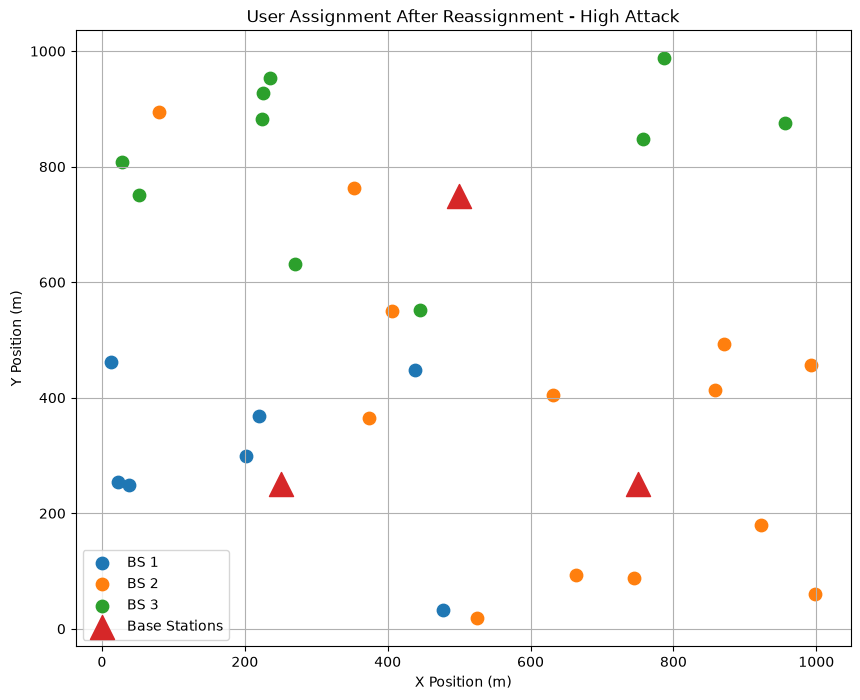

In [135]:
# STEP 17.7 - Visualize User Assignment Changes

scenario_to_plot = "High Attack"

new_assignments = (
    reassignment_results[scenario_to_plot]
    ["assignments"]
)

plt.figure(figsize=(10, 8))

for bs in range(num_bs):

    users = user_positions[
        new_assignments == bs
    ]

    plt.scatter(
        users[:, 0],
        users[:, 1],
        s=80,
        label=f"BS {bs+1}"
    )

# Plot base stations
plt.scatter(
    bs_positions[:, 0],
    bs_positions[:, 1],
    marker="^",
    s=300,
    label="Base Stations"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title(
    f"User Assignment After Reassignment - {scenario_to_plot}"
)

plt.grid(True)
plt.legend()

plt.show()

In [136]:
# STEP 17.8 - Number of Users Whose Assignment Changed

assignment_change_results = {}

for scenario in scenario_names:

    new_assignments = (
        reassignment_results[scenario]
        ["assignments"]
    )

    changed_users = np.sum(
        new_assignments != original_assignments
    )

    assignment_change_results[scenario] = changed_users

    print(
        f"{scenario}: "
        f"{changed_users} users reassigned"
    )

Normal: 0 users reassigned
Low Attack: 0 users reassigned
Medium Attack: 0 users reassigned
High Attack: 4 users reassigned


In [137]:
# ============================================================
# STEP 18 - QoS Comparison Before and After User Reassignment
# ============================================================
# STEP 18.1 - BS Utilization After Reassignment

utilization_after_reassignment = {}

for scenario in scenario_names:

    load_after = reassignment_results[scenario]["load"]

    utilization_after = (
        load_after / bs_capacity
    ) * 100

    utilization_after_reassignment[scenario] = utilization_after

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):
        print(
            f"BS {bs+1}: "
            f"{utilization_after[bs]:.2f}% utilization"
        )


===== NORMAL =====
BS 1: 54.81% utilization
BS 2: 25.80% utilization
BS 3: 82.19% utilization

===== LOW ATTACK =====
BS 1: 66.15% utilization
BS 2: 55.10% utilization
BS 3: 82.25% utilization

===== MEDIUM ATTACK =====
BS 1: 65.23% utilization
BS 2: 82.44% utilization
BS 3: 96.54% utilization

===== HIGH ATTACK =====
BS 1: 99.54% utilization
BS 2: 99.95% utilization
BS 3: 126.12% utilization


In [138]:
# STEP 18.2 - Achieved Throughput After Reassignment

throughput_after_reassignment = {}

for scenario in scenario_names:

    load_after = reassignment_results[scenario]["load"]

    achieved_throughput = np.minimum(
        load_after,
        bs_capacity
    )

    throughput_after_reassignment[scenario] = (
        achieved_throughput
    )

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):
        print(
            f"BS {bs+1}: "
            f"{achieved_throughput[bs]:.2f} Mbps"
        )

    print(
        f"Total Throughput: "
        f"{np.sum(achieved_throughput):.2f} Mbps"
    )


===== NORMAL =====
BS 1: 54.81 Mbps
BS 2: 25.80 Mbps
BS 3: 82.19 Mbps
Total Throughput: 162.80 Mbps

===== LOW ATTACK =====
BS 1: 66.15 Mbps
BS 2: 55.10 Mbps
BS 3: 82.25 Mbps
Total Throughput: 203.50 Mbps

===== MEDIUM ATTACK =====
BS 1: 65.23 Mbps
BS 2: 82.44 Mbps
BS 3: 96.54 Mbps
Total Throughput: 244.21 Mbps

===== HIGH ATTACK =====
BS 1: 99.54 Mbps
BS 2: 99.95 Mbps
BS 3: 100.00 Mbps
Total Throughput: 299.48 Mbps


In [139]:
# STEP 18.3 - Packet Loss After Reassignment

packet_loss_after_reassignment = {}

for scenario in scenario_names:

    load_after = reassignment_results[scenario]["load"]

    excess_after = np.maximum(
        load_after - bs_capacity,
        0
    )

    packet_loss = (
        excess_after /
        np.maximum(load_after, 0.001)
    ) * 100

    packet_loss_after_reassignment[scenario] = packet_loss

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):
        print(
            f"BS {bs+1}: "
            f"{packet_loss[bs]:.2f}% packet loss"
        )


===== NORMAL =====
BS 1: 0.00% packet loss
BS 2: 0.00% packet loss
BS 3: 0.00% packet loss

===== LOW ATTACK =====
BS 1: 0.00% packet loss
BS 2: 0.00% packet loss
BS 3: 0.00% packet loss

===== MEDIUM ATTACK =====
BS 1: 0.00% packet loss
BS 2: 0.00% packet loss
BS 3: 0.00% packet loss

===== HIGH ATTACK =====
BS 1: 0.00% packet loss
BS 2: 0.00% packet loss
BS 3: 20.71% packet loss


In [140]:
# STEP 18.4 - Latency After Reassignment

base_latency = 10.0

latency_after_reassignment = {}

for scenario in scenario_names:

    utilization = (
        utilization_after_reassignment[scenario]
    )

    safe_utilization = np.minimum(
        utilization,
        99
    )

    latency = (
        base_latency /
        (1 - safe_utilization / 100)
    )

    # Additional penalty for congestion
    congested = utilization >= 100

    latency[congested] = (
        base_latency *
        (1 + utilization[congested] / 50)
    )

    latency_after_reassignment[scenario] = latency

    print(f"\n===== {scenario.upper()} =====")

    for bs in range(num_bs):
        print(
            f"BS {bs+1}: "
            f"{latency[bs]:.2f} ms"
        )


===== NORMAL =====
BS 1: 22.13 ms
BS 2: 13.48 ms
BS 3: 56.15 ms

===== LOW ATTACK =====
BS 1: 29.54 ms
BS 2: 22.27 ms
BS 3: 56.34 ms

===== MEDIUM ATTACK =====
BS 1: 28.76 ms
BS 2: 56.95 ms
BS 3: 288.68 ms

===== HIGH ATTACK =====
BS 1: 1000.00 ms
BS 2: 1000.00 ms
BS 3: 35.22 ms


In [141]:
# STEP 18.5 - Network-Level QoS Comparison

qos_before_after = []

for scenario in scenario_names:

    # BEFORE reassignment
    throughput_before = np.sum(
        throughput_results[scenario]
    )

    latency_before = np.mean(
        latency_results[scenario]
    )

    packet_loss_before = np.mean(
        packet_loss_results[scenario]
    )

    # AFTER reassignment
    throughput_after = np.sum(
        throughput_after_reassignment[scenario]
    )

    latency_after = np.mean(
        latency_after_reassignment[scenario]
    )

    packet_loss_after = np.mean(
        packet_loss_after_reassignment[scenario]
    )

    reassigned_count = assignment_change_results[scenario]

    qos_before_after.append({
        "Scenario": scenario,

        "Throughput Before (Mbps)": round(
            throughput_before, 2
        ),

        "Throughput After (Mbps)": round(
            throughput_after, 2
        ),

        "Latency Before (ms)": round(
            latency_before, 2
        ),

        "Latency After (ms)": round(
            latency_after, 2
        ),

        "Packet Loss Before (%)": round(
            packet_loss_before, 2
        ),

        "Packet Loss After (%)": round(
            packet_loss_after, 2
        ),

        "Users Reassigned": reassigned_count
    })

qos_before_after_df = pd.DataFrame(
    qos_before_after
)

qos_before_after_df

,Scenario,Throughput Before (Mbps),Throughput After (Mbps),Latency Before (ms),Latency After (ms),Packet Loss Before (%),Packet Loss After (%),Users Reassigned
0,Normal,162.80,162.80,30.59,30.59,0.00,0.0,0
1,Low Attack,203.50,203.50,36.05,36.05,0.00,0.0,0
2,Medium Attack,244.21,244.21,124.80,124.80,0.00,0.0,0
3,High Attack,257.74,299.48,32.41,678.41,16.19,6.9,4


In [142]:
# STEP 18.6 - Calculate QoS Improvement

qos_improvement = []

for scenario in scenario_names:

    throughput_before = np.sum(
        throughput_results[scenario]
    )

    throughput_after = np.sum(
        throughput_after_reassignment[scenario]
    )

    latency_before = np.mean(
        latency_results[scenario]
    )

    latency_after = np.mean(
        latency_after_reassignment[scenario]
    )

    loss_before = np.mean(
        packet_loss_results[scenario]
    )

    loss_after = np.mean(
        packet_loss_after_reassignment[scenario]
    )

    throughput_change = (
        (throughput_after - throughput_before)
        / max(throughput_before, 0.001)
    ) * 100

    latency_change = (
        (latency_before - latency_after)
        / max(latency_before, 0.001)
    ) * 100

    packet_loss_change = (
        (loss_before - loss_after)
        / max(loss_before, 0.001)
    ) * 100 if loss_before > 0 else 0

    qos_improvement.append({
        "Scenario": scenario,
        "Throughput Improvement (%)": round(
            throughput_change, 2
        ),
        "Latency Improvement (%)": round(
            latency_change, 2
        ),
        "Packet Loss Reduction (%)": round(
            packet_loss_change, 2
        )
    })

qos_improvement_df = pd.DataFrame(
    qos_improvement
)

qos_improvement_df

,Scenario,Throughput Improvement (%),Latency Improvement (%),Packet Loss Reduction (%)
0,Normal,0.0,0.00,0.00
1,Low Attack,0.0,0.00,0.00
2,Medium Attack,0.0,0.00,0.00
3,High Attack,16.2,-1993.06,57.36


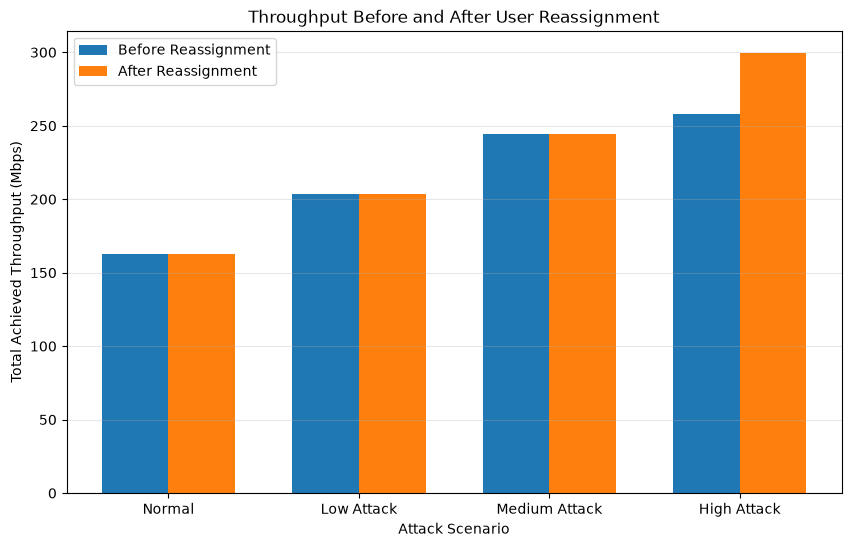

In [143]:
# STEP 18.7 - Throughput Comparison

throughput_before_values = [
    np.sum(throughput_results[s])
    for s in scenario_names
]

throughput_after_values = [
    np.sum(throughput_after_reassignment[s])
    for s in scenario_names
]

x = np.arange(len(scenario_names))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    throughput_before_values,
    width,
    label="Before Reassignment"
)

plt.bar(
    x + width/2,
    throughput_after_values,
    width,
    label="After Reassignment"
)

plt.xticks(
    x,
    scenario_names
)

plt.xlabel("Attack Scenario")
plt.ylabel("Total Achieved Throughput (Mbps)")
plt.title(
    "Throughput Before and After User Reassignment"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

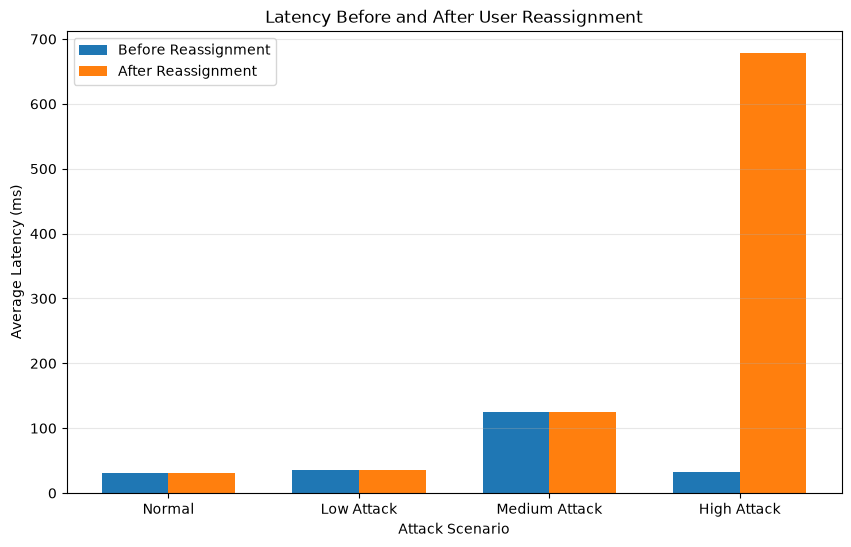

In [144]:
# STEP 18.8 - Latency Comparison

latency_before_values = [
    np.mean(latency_results[s])
    for s in scenario_names
]

latency_after_values = [
    np.mean(latency_after_reassignment[s])
    for s in scenario_names
]

x = np.arange(len(scenario_names))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    latency_before_values,
    width,
    label="Before Reassignment"
)

plt.bar(
    x + width/2,
    latency_after_values,
    width,
    label="After Reassignment"
)

plt.xticks(
    x,
    scenario_names
)

plt.xlabel("Attack Scenario")
plt.ylabel("Average Latency (ms)")
plt.title(
    "Latency Before and After User Reassignment"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

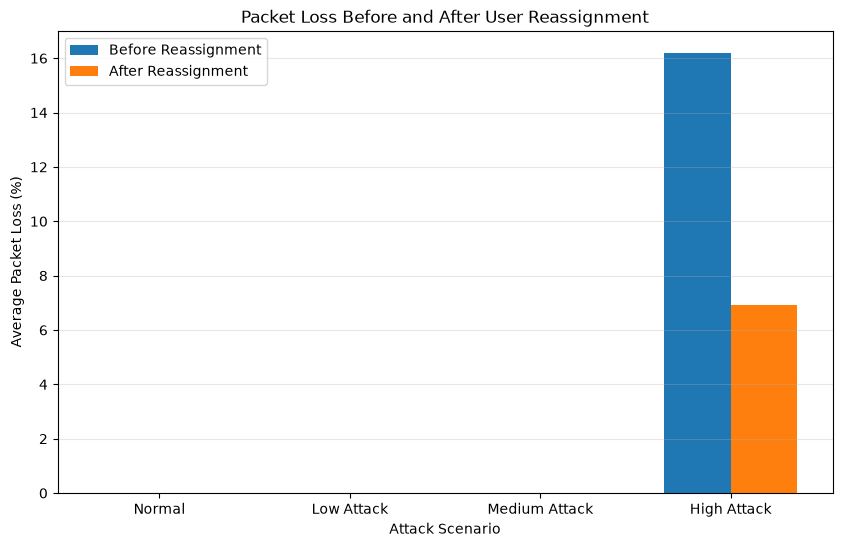

In [145]:
# STEP 18.9 - Packet Loss Comparison

loss_before_values = [
    np.mean(packet_loss_results[s])
    for s in scenario_names
]

loss_after_values = [
    np.mean(packet_loss_after_reassignment[s])
    for s in scenario_names
]

x = np.arange(len(scenario_names))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    loss_before_values,
    width,
    label="Before Reassignment"
)

plt.bar(
    x + width/2,
    loss_after_values,
    width,
    label="After Reassignment"
)

plt.xticks(
    x,
    scenario_names
)

plt.xlabel("Attack Scenario")
plt.ylabel("Average Packet Loss (%)")
plt.title(
    "Packet Loss Before and After User Reassignment"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()